<a href="https://colab.research.google.com/github/princerm06/precipitation-geoai/blob/main/UNG_PIDF_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Georgia Precipitation Frequency GeoAI / PIDF Modeling

## Project Overview

This project develops a geospatial machine learning workflow for estimating
precipitation-frequency depths across Georgia using NOAA Atlas 14 data.

The workflow converts NOAA precipitation-frequency raster grids into
machine-learning-ready spatial datasets and evaluates regression models using
spatial block validation.

The current model predicts precipitation depth using:

- Latitude
- Longitude
- Storm duration
- Return period

The resulting predictions are used to generate precipitation depth and
intensity-duration-frequency (IDF/PIDF) curves for locations across Georgia.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving se200yr24ha.zip to se200yr24ha.zip


In [ ]:
import zipfile
import os

zip_path = "se200yr24ha.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("se200yr24ha")

os.listdir("se200yr24ha")

['se200yr24ha.xml', 'se200yr24ha.prj', 'se200yr24ha.asc']

In [ ]:
asc_path = "se200yr24ha/se200yr24ha.asc"

with open(asc_path, "r") as f:
    for i in range(6):
        print(f.readline().strip())

ncols 1796
nrows 1480
xllcorner -94.920800
yllcorner 24.462500
cellsize 0.008333
NODATA_value -9


In [ ]:
import numpy as np
import pandas as pd

# Read header
header = {}

with open(asc_path, "r") as f:
    for _ in range(6):
        key, value = f.readline().split()
        header[key.lower()] = float(value)

ncols = int(header["ncols"])
nrows = int(header["nrows"])
xllcorner = header["xllcorner"]
yllcorner = header["yllcorner"]
cellsize = header["cellsize"]
nodata = header["nodata_value"]

print(header)

{'ncols': 1796.0, 'nrows': 1480.0, 'xllcorner': -94.9208, 'yllcorner': 24.4625, 'cellsize': 0.008333, 'nodata_value': -9.0}


## 1. NOAA Atlas 14 Data Preparation

This section loads NOAA Atlas 14 precipitation-frequency raster data,
converts the raster grid into latitude/longitude point data, removes missing
values, and converts precipitation depth from thousandths of inches to inches.

The initial prototype used a rough latitude/longitude bounding box to isolate
Georgia. This will later be replaced with an official Georgia state boundary
clip.

In [ ]:
# Load precipitation grid values
grid = np.loadtxt(asc_path, skiprows=6)

print(grid.shape)
print("Min:", np.nanmin(grid))
print("Max:", np.nanmax(grid))

(1480, 1796)
Min: -9.0
Max: 19738.0


In [ ]:
# Create row and column indexes
rows, cols = np.indices(grid.shape)

# Convert grid cells to lon/lat center points
lon = xllcorner + cols * cellsize + cellsize / 2
lat = yllcorner + (nrows - rows - 1) * cellsize + cellsize / 2

# Flatten into table
df = pd.DataFrame({
    "lat": lat.ravel(),
    "lon": lon.ravel(),
    "precip_depth": grid.ravel()
})

# Remove no-data cells
df = df[df["precip_depth"] != nodata].copy()

df.head()

,lat,lon,precip_depth
61100,36.507851,-94.616646,9380.0
61101,36.507851,-94.608312,9363.0
61102,36.507851,-94.599980,9347.0
61103,36.507851,-94.591647,9330.0
61104,36.507851,-94.583314,9313.0


In [ ]:
# Check the dataset size
print("Dataset shape:", df.shape)

# Show the first few rows
display(df.head())

# Show summary statistics
display(df.describe())

Dataset shape: (1179532, 3)


,lat,lon,precip_depth
61100,36.507851,-94.616646,9380.0
61101,36.507851,-94.608312,9363.0
61102,36.507851,-94.599980,9347.0
61103,36.507851,-94.591647,9330.0
61104,36.507851,-94.583314,9313.0


,lat,lon,precip_depth
count,1.179532e+06,1.179532e+06,1.179532e+06
mean,3.200797e+01,-8.752136e+01,1.191198e+04
std,2.405692e+00,4.137622e+00,2.691148e+03
min,2.446667e+01,-9.462498e+01,7.321000e+03
25%,3.055809e+01,-9.119178e+01,9.718000e+03
50%,3.218302e+01,-8.780858e+01,1.107600e+04
75%,3.381629e+01,-8.369208e+01,1.381100e+04
max,3.650785e+01,-7.995890e+01,1.973800e+04


### Georgia Spatial Filtering

Georgia is isolated using the official U.S. Census TIGER/Line state boundary rather than a latitude/longitude bounding box.

NOAA raster cells are converted to geographic point features and spatially clipped to the Georgia state boundary before model training.

In [ ]:
import geopandas as gpd

# Official 2025 U.S. Census TIGER/Line state boundaries
states_url = "https://www2.census.gov/geo/tiger/TIGER2025/STATE/tl_2025_us_state.zip"

states = gpd.read_file(states_url)

# Georgia = state FIPS code 13
georgia_boundary = states[states["STATEFP"] == "13"].copy()

georgia_boundary

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
12,3,5,13,01705317,13,0400000US13,GA,Georgia,00,G4000,A,149487720450,4417264043,+32.6295789,-083.4235109,"POLYGON ((-81.09538 31.52098, -81.0971 31.5197..."


In [ ]:
# Convert NOAA precipitation points to geographic point features
points = gpd.GeoDataFrame(
    df.copy(),
    geometry=gpd.points_from_xy(df["lon"], df["lat"]),
    crs="EPSG:4326"
)

# Make sure the official Georgia boundary uses the same coordinate system
georgia_boundary = georgia_boundary.to_crs("EPSG:4326")

# Keep only precipitation points inside the official Georgia boundary
ga = gpd.sjoin(
    points,
    georgia_boundary[["geometry"]],
    how="inner",
    predicate="within"
).copy()

# Remove spatial-join helper column
ga = ga.drop(columns=["index_right"], errors="ignore")

# Convert back to a regular pandas DataFrame for downstream ML code
ga = pd.DataFrame(ga.drop(columns=["geometry"]))

print("Georgia dataset shape:", ga.shape)
display(ga.head())
display(ga.describe())

Georgia dataset shape: (212762, 3)


,lat,lon,precip_depth
387549,34.999578,-83.175437,14996.0
387550,34.999578,-83.167103,15217.0
387551,34.999578,-83.158771,15429.0
387552,34.999578,-83.150438,15614.0
387553,34.999578,-83.142105,15758.0


,lat,lon,precip_depth
count,212762.000000,212762.000000,212762.000000
mean,32.640451,-83.430464,9809.452501
std,1.195375,1.109451,1416.676710
min,30.358097,-85.600340,7321.000000
25%,31.633046,-84.358722,8831.000000
50%,32.558009,-83.500424,9403.000000
75%,33.599634,-82.558795,10328.000000
max,34.999578,-80.800532,16690.000000


In [ ]:
ga.to_csv("georgia_200yr_24hr_precip.csv", index=False)

from google.colab import files
files.download("georgia_200yr_24hr_precip.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

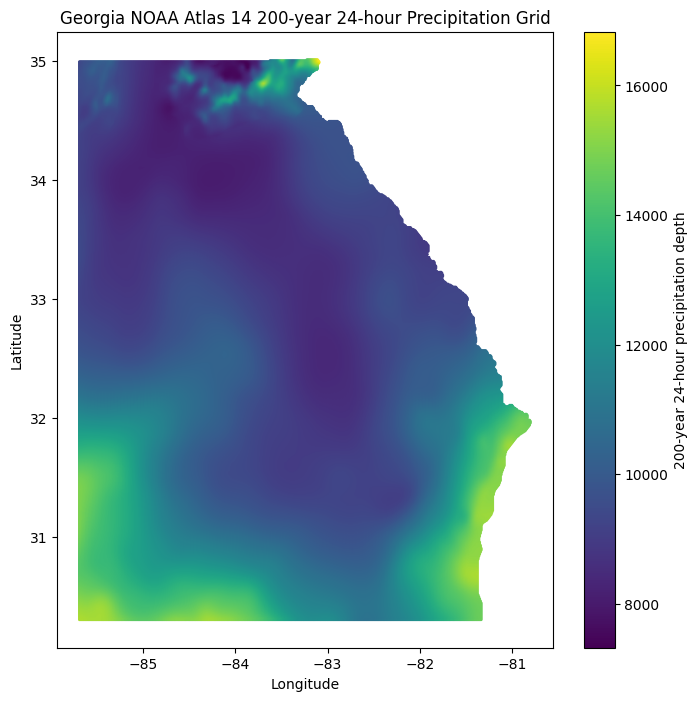

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(ga["lon"], ga["lat"], c=ga["precip_depth"], s=1)
plt.colorbar(label="200-year 24-hour precipitation depth")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Georgia NOAA Atlas 14 200-year 24-hour Precipitation Grid")
plt.show()

### Precipitation Unit Conversion

NOAA Atlas 14 raster values are stored in thousandths of an inch.
The raw precipitation depths are converted to inches before model training.

In [ ]:
ga["precip_depth_in"] = ga["precip_depth"] / 1000

ga[["lat", "lon", "precip_depth", "precip_depth_in"]].head()

,lat,lon,precip_depth,precip_depth_in
387549,34.999578,-83.175437,14996.0,14.996
387550,34.999578,-83.167103,15217.0,15.217
387551,34.999578,-83.158771,15429.0,15.429
387552,34.999578,-83.150438,15614.0,15.614
387553,34.999578,-83.142105,15758.0,15.758


## 2. Random Forest Baseline

A Random Forest regression model is used as the initial machine learning
baseline to estimate precipitation depth from geographic location.

The first experiment uses latitude and longitude as input features and
precipitation depth in inches as the prediction target.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Inputs: location only
X = ga[["lat", "lon"]]

# Target: 200-year 24-hour precipitation depth in inches
y = ga["precip_depth_in"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.0038678302352360906
RMSE: 0.011151286084403725
R²: 0.9999377016327622


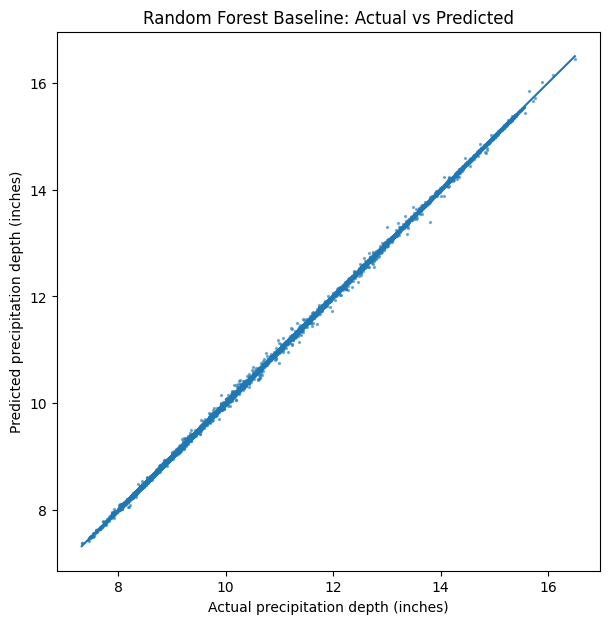

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, s=2, alpha=0.5)
plt.xlabel("Actual precipitation depth (inches)")
plt.ylabel("Predicted precipitation depth (inches)")
plt.title("Random Forest Baseline: Actual vs Predicted")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [ ]:
results = X_test.copy()
results["actual_depth_in"] = y_test
results["predicted_depth_in"] = y_pred
results["error_in"] = results["predicted_depth_in"] - results["actual_depth_in"]
results["absolute_error_in"] = abs(results["error_in"])

results.head()

,lat,lon,actual_depth_in,predicted_depth_in,error_in,absolute_error_in
944236,32.416348,-83.783746,9.887,9.88479,-0.00221,0.00221
1285657,30.833078,-82.275473,11.282,11.26499,-0.01701,0.01701
1169022,31.374723,-81.400508,14.422,14.43751,0.01551,0.01551
1145316,31.483052,-84.383722,10.018,10.02537,0.00737,0.00737
496976,34.491265,-84.250394,9.136,9.14833,0.01233,0.01233


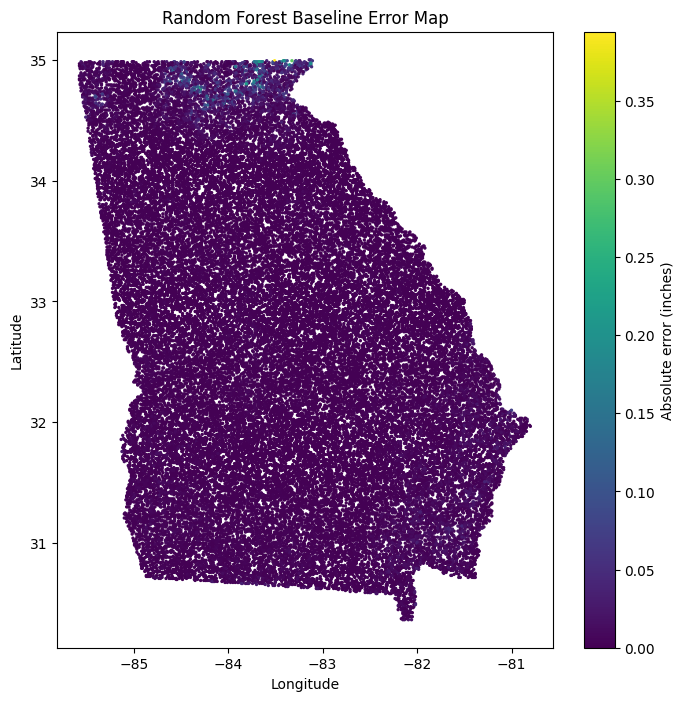

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(results["lon"], results["lat"], c=results["absolute_error_in"], s=2)
plt.colorbar(label="Absolute error (inches)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Forest Baseline Error Map")
plt.show()

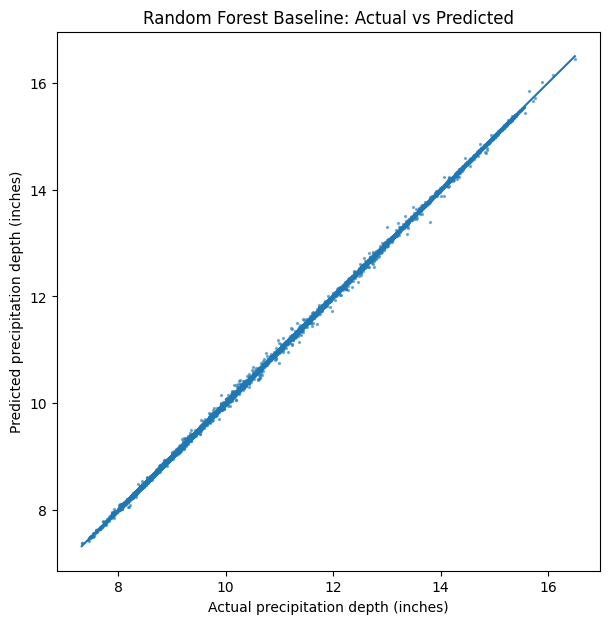

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, s=2, alpha=0.5)
plt.xlabel("Actual precipitation depth (inches)")
plt.ylabel("Predicted precipitation depth (inches)")
plt.title("Random Forest Baseline: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [ ]:
metrics = pd.DataFrame({
    "Model": ["Random Forest Baseline"],
    "Features": ["Latitude, Longitude"],
    "Target": ["200-year 24-hour precipitation depth"],
    "MAE_inches": [mae],
    "RMSE_inches": [rmse],
    "R2": [r2]
})

metrics

,Model,Features,Target,MAE_inches,RMSE_inches,R2
0,Random Forest Baseline,"Latitude, Longitude",200-year 24-hour precipitation depth,0.003868,0.011151,0.999938


In [ ]:
results.to_csv("random_forest_baseline_predictions.csv", index=False)
metrics.to_csv("random_forest_baseline_metrics.csv", index=False)

files.download("random_forest_baseline_predictions.csv")
files.download("random_forest_baseline_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Spatial Validation

In [ ]:
# Spatial holdout:
# Train on western/central Georgia, test on eastern Georgia

split_lon = ga["lon"].quantile(0.8)

train_spatial = ga[ga["lon"] <= split_lon].copy()
test_spatial = ga[ga["lon"] > split_lon].copy()

X_train_spatial = train_spatial[["lat", "lon"]]
y_train_spatial = train_spatial["precip_depth_in"]

X_test_spatial = test_spatial[["lat", "lon"]]
y_test_spatial = test_spatial["precip_depth_in"]

rf_spatial = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_spatial.fit(X_train_spatial, y_train_spatial)

y_pred_spatial = rf_spatial.predict(X_test_spatial)

mae_spatial = mean_absolute_error(y_test_spatial, y_pred_spatial)
rmse_spatial = np.sqrt(mean_squared_error(y_test_spatial, y_pred_spatial))
r2_spatial = r2_score(y_test_spatial, y_pred_spatial)

print("Spatial Holdout MAE:", mae_spatial)
print("Spatial Holdout RMSE:", rmse_spatial)
print("Spatial Holdout R²:", r2_spatial)

Spatial Holdout MAE: 1.6250928561616258
Spatial Holdout RMSE: 2.3139432951179133
Spatial Holdout R²: -0.625418531436047


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# Create spatial blocks by rounding lat/lon into larger grid boxes
ga["lat_block"] = (ga["lat"] // 0.25).astype(int)
ga["lon_block"] = (ga["lon"] // 0.25).astype(int)

# Each block gets a group ID
ga["spatial_block"] = ga["lat_block"].astype(str) + "_" + ga["lon_block"].astype(str)

X = ga[["lat", "lon"]]
y = ga["precip_depth_in"]
groups = ga["spatial_block"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train_block = X.iloc[train_idx]
X_test_block = X.iloc[test_idx]
y_train_block = y.iloc[train_idx]
y_test_block = y.iloc[test_idx]

rf_block = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_block.fit(X_train_block, y_train_block)

y_pred_block = rf_block.predict(X_test_block)

mae_block = mean_absolute_error(y_test_block, y_pred_block)
rmse_block = np.sqrt(mean_squared_error(y_test_block, y_pred_block))
r2_block = r2_score(y_test_block, y_pred_block)

print("Spatial Block MAE:", mae_block)
print("Spatial Block RMSE:", rmse_block)
print("Spatial Block R²:", r2_block)

Spatial Block MAE: 0.13678145324239988
Spatial Block RMSE: 0.31730691716136755
Spatial Block R²: 0.9453847318801425


In [ ]:
block_results = X_test_block.copy()
block_results["actual_depth_in"] = y_test_block
block_results["predicted_depth_in"] = y_pred_block
block_results["error_in"] = block_results["predicted_depth_in"] - block_results["actual_depth_in"]
block_results["absolute_error_in"] = abs(block_results["error_in"])

block_results.head()

,lat,lon,actual_depth_in,predicted_depth_in,error_in,absolute_error_in
387511,34.999578,-83.492091,14.468,14.21202,-0.25598,0.25598
387512,34.999578,-83.483757,14.485,14.21202,-0.27298,0.27298
387513,34.999578,-83.475425,14.374,14.21202,-0.16198,0.16198
387514,34.999578,-83.467092,14.084,14.21202,0.12802,0.12802
387515,34.999578,-83.458759,13.706,14.21202,0.50602,0.50602


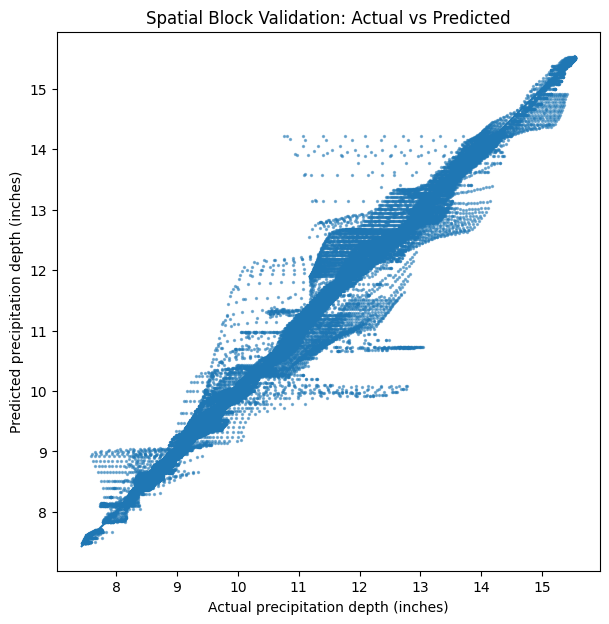

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test_block, y_pred_block, s=2, alpha=0.5)
plt.xlabel("Actual precipitation depth (inches)")
plt.ylabel("Predicted precipitation depth (inches)")
plt.title("Spatial Block Validation: Actual vs Predicted")

plt.plot(
    [y_test_block.min(), y_test_block.max()],
    [y_test_block.min(), y_test_block.max()]
)

plt.show()

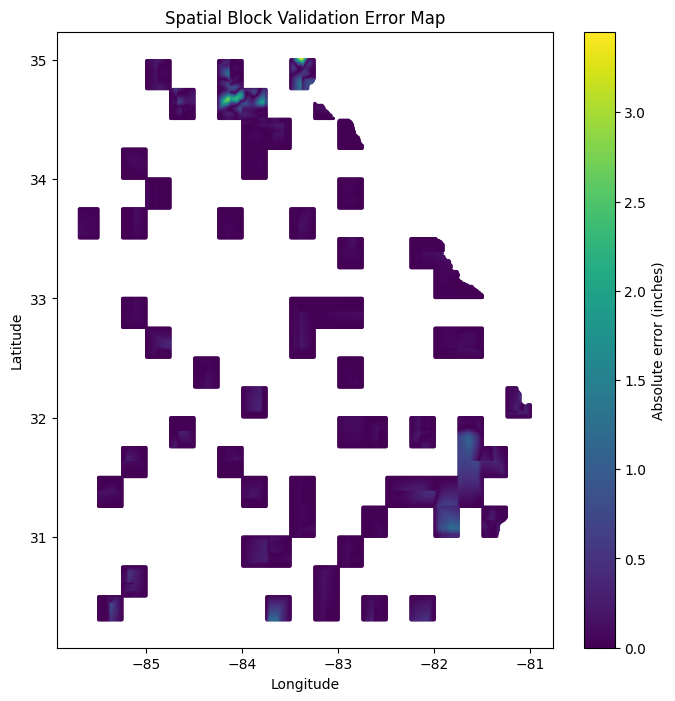

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    block_results["lon"],
    block_results["lat"],
    c=block_results["absolute_error_in"],
    s=2
)

plt.colorbar(label="Absolute error (inches)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Block Validation Error Map")
plt.show()

In [ ]:
block_results.sort_values("absolute_error_in", ascending=False).head(20)

,lat,lon,actual_depth_in,predicted_depth_in,error_in,absolute_error_in
387525,34.999578,-83.375428,10.760,14.21130,3.45130,3.45130
387524,34.999578,-83.383762,10.811,14.21202,3.40102,3.40102
387526,34.999578,-83.367096,10.859,14.16984,3.31084,3.31084
387523,34.999578,-83.392094,11.076,14.21202,3.13602,3.13602
387527,34.999578,-83.358762,11.102,14.15480,3.05280,3.05280
389322,34.991245,-83.367096,11.065,14.04559,2.98059,2.98059
389321,34.991245,-83.375428,10.937,13.91625,2.97925,2.97925
389320,34.991245,-83.383762,10.965,13.91120,2.94620,2.94620
387522,34.999578,-83.400428,11.404,14.21202,2.80802,2.80802
389319,34.991245,-83.392094,11.151,13.91120,2.76020,2.76020


In [ ]:
block_results["absolute_error_in"].describe()

,absolute_error_in
count,54836.000000
mean,0.121051
std,0.225493
min,0.000000
25%,0.016160
50%,0.045550
75%,0.114385
max,3.451300


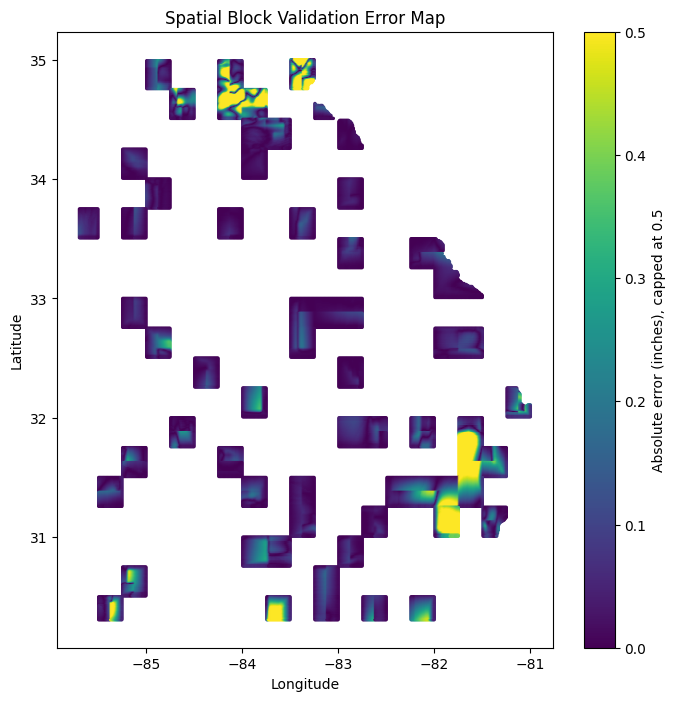

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    block_results["lon"],
    block_results["lat"],
    c=block_results["absolute_error_in"],
    s=2,
    vmin=0,
    vmax=0.5
)

plt.colorbar(label="Absolute error (inches), capped at 0.5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Block Validation Error Map")
plt.show()

In [ ]:
block_results.to_csv("spatial_block_validation_predictions.csv", index=False)

block_metrics = pd.DataFrame({
    "Model": ["Random Forest Spatial Block Validation"],
    "Features": ["Latitude, Longitude"],
    "Target": ["200-year 24-hour precipitation depth"],
    "MAE_inches": [mae_block],
    "RMSE_inches": [rmse_block],
    "R2": [r2_block]
})

block_metrics.to_csv("spatial_block_validation_metrics.csv", index=False)

files.download("spatial_block_validation_predictions.csv")
files.download("spatial_block_validation_metrics.csv")

block_metrics

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Model,Features,Target,MAE_inches,RMSE_inches,R2
0,Random Forest Spatial Block Validation,"Latitude, Longitude",200-year 24-hour precipitation depth,0.121051,0.255929,0.978479


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data.txt to data.txt


## 4. Elevation and XGBoost Experiments

In [ ]:
import os
import urllib.request

os.makedirs("dem_tiles", exist_ok=True)

with open("data.txt", "r") as f:
    urls = [line.strip() for line in f if line.strip().startswith("http")]

print("Number of DEM links:", len(urls))

for i, url in enumerate(urls, start=1):
    filename = url.split("/")[-1]
    out_path = os.path.join("dem_tiles", filename)

    if not os.path.exists(out_path):
        print(f"Downloading {i}/{len(urls)}: {filename}")
        urllib.request.urlretrieve(url, out_path)
    else:
        print(f"Already exists: {filename}")

print("Done.")
print(os.listdir("dem_tiles")[:5])

Number of DEM links: 35
Done.
['USGS_1_n33w084_20230215.tif', 'USGS_1_n35w085_20260429.tif', 'USGS_1_n32w081_20220725.tif', 'USGS_1_n34w086_20260609.tif', 'USGS_1_n36w085_20260429.tif']


In [ ]:
!pip install rasterio

In [ ]:
import glob

dem_files = glob.glob("dem_tiles/*.tif")

print("Number of DEM files:", len(dem_files))
print(dem_files[:5])

Number of DEM files: 35
['dem_tiles/USGS_1_n33w084_20230215.tif', 'dem_tiles/USGS_1_n35w085_20260429.tif', 'dem_tiles/USGS_1_n32w081_20220725.tif', 'dem_tiles/USGS_1_n34w086_20260609.tif', 'dem_tiles/USGS_1_n36w085_20260429.tif']


In [ ]:
import rasterio
import numpy as np
from rasterio.errors import RasterioIOError

# Start with empty elevation column
ga["elevation_m"] = np.nan

# Coordinates to sample
coords = list(zip(ga["lon"], ga["lat"]))

for dem_file in dem_files:
    print("Sampling:", dem_file)

    try:
        with rasterio.open(dem_file) as src:
            bounds = src.bounds

            # Find points inside this DEM tile
            mask = (
                (ga["lon"] >= bounds.left) &
                (ga["lon"] <= bounds.right) &
                (ga["lat"] >= bounds.bottom) &
                (ga["lat"] <= bounds.top)
            )

            if mask.sum() == 0:
                continue

            tile_coords = list(zip(ga.loc[mask, "lon"], ga.loc[mask, "lat"]))

            sampled_values = [val[0] for val in src.sample(tile_coords)]

            ga.loc[mask, "elevation_m"] = sampled_values

    except RasterioIOError:
        print("Could not read:", dem_file)

ga[["lat", "lon", "precip_depth_in", "elevation_m"]].head()

Sampling: dem_tiles/USGS_1_n33w084_20230215.tif
Sampling: dem_tiles/USGS_1_n35w085_20260429.tif
Sampling: dem_tiles/USGS_1_n32w081_20220725.tif
Sampling: dem_tiles/USGS_1_n34w086_20260609.tif
Sampling: dem_tiles/USGS_1_n36w085_20260429.tif
Sampling: dem_tiles/USGS_1_n31w084_20230215.tif
Sampling: dem_tiles/USGS_1_n36w084_20220725.tif
Sampling: dem_tiles/USGS_1_n34w085_20260326.tif
Sampling: dem_tiles/USGS_1_n36w082_20260417.tif
Sampling: dem_tiles/USGS_1_n34w081_20220504.tif
Sampling: dem_tiles/USGS_1_n36w081_20260417.tif
Sampling: dem_tiles/USGS_1_n35w082_20260417.tif
Sampling: dem_tiles/USGS_1_n35w081_20260417.tif
Sampling: dem_tiles/USGS_1_n34w084_20230215.tif
Sampling: dem_tiles/USGS_1_n34w083_20230215.tif
Sampling: dem_tiles/USGS_1_n35w086_20260609.tif
Sampling: dem_tiles/USGS_1_n33w082_20220725.tif
Sampling: dem_tiles/USGS_1_n32w084_20230215.tif
Sampling: dem_tiles/USGS_1_n32w083_20220725.tif
Sampling: dem_tiles/USGS_1_n31w083_20221103.tif
Sampling: dem_tiles/USGS_1_n32w086_20260

,lat,lon,precip_depth_in,elevation_m
385747,35.007911,-83.225435,14.294,785.358826
385748,35.007911,-83.217101,14.367,780.848389
385749,35.007911,-83.208769,14.464,802.072754
385750,35.007911,-83.200435,14.586,874.974060
385751,35.007911,-83.192103,14.730,888.990723


In [ ]:
ga["elevation_m"].describe()
ga["elevation_m"].isna().sum()

np.int64(0)

In [ ]:
print(ga["elevation_m"].describe())

count    265760.000000
mean        143.990262
std         139.772994
min          -2.054761
25%          49.761399
50%          99.139999
75%         208.376934
max        1475.498291
Name: elevation_m, dtype: float64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Features now include elevation
X_elev = ga[["lat", "lon", "elevation_m"]]
y = ga["precip_depth_in"]

# Reuse the spatial blocks
groups = ga["spatial_block"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_elev, y, groups))

X_train_elev = X_elev.iloc[train_idx]
X_test_elev = X_elev.iloc[test_idx]
y_train_elev = y.iloc[train_idx]
y_test_elev = y.iloc[test_idx]

rf_elev = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_elev.fit(X_train_elev, y_train_elev)

y_pred_elev = rf_elev.predict(X_test_elev)

mae_elev = mean_absolute_error(y_test_elev, y_pred_elev)
rmse_elev = np.sqrt(mean_squared_error(y_test_elev, y_pred_elev))
r2_elev = r2_score(y_test_elev, y_pred_elev)

print("RF + Elevation MAE:", mae_elev)
print("RF + Elevation RMSE:", rmse_elev)
print("RF + Elevation R²:", r2_elev)

RF + Elevation MAE: 0.13210570884090753
RF + Elevation RMSE: 0.28221047285640066
RF + Elevation R²: 0.973831558589486


In [ ]:
feature_importance = pd.DataFrame({
    "feature": X_elev.columns,
    "importance": rf_elev.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,lat,0.562936
1,lon,0.268067
2,elevation_m,0.168997


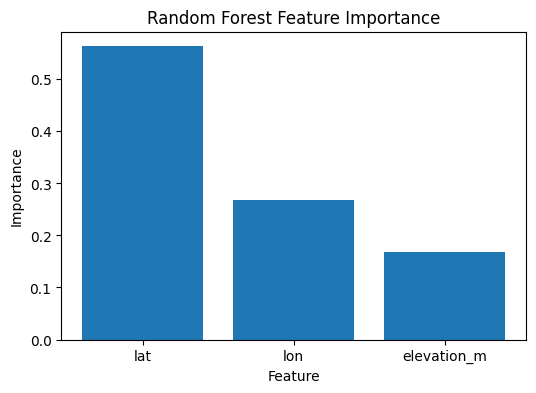

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_elev, y_train_elev)

y_pred_xgb = xgb.predict(X_test_elev)

mae_xgb = mean_absolute_error(y_test_elev, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_elev, y_pred_xgb))
r2_xgb = r2_score(y_test_elev, y_pred_xgb)

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)
print("XGBoost R²:", r2_xgb)

XGBoost MAE: 0.20695464154912066
XGBoost RMSE: 0.3655057469140867
XGBoost R²: 0.9561044976344177


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + Elevation",
        "XGBoost + Elevation"
    ],
    "Features": [
        "lat, lon",
        "lat, lon, elevation",
        "lat, lon, elevation"
    ],
    "Validation": [
        "Spatial block",
        "Spatial block",
        "Spatial block"
    ],
    "MAE_inches": [
        mae_block,
        mae_elev,
        mae_xgb
    ],
    "RMSE_inches": [
        rmse_block,
        rmse_elev,
        rmse_xgb
    ],
    "R2": [
        r2_block,
        r2_elev,
        r2_xgb
    ]
})

model_comparison

,Model,Features,Validation,MAE_inches,RMSE_inches,R2
0,Random Forest,"lat, lon",Spatial block,0.121051,0.255929,0.978479
1,Random Forest + Elevation,"lat, lon, elevation",Spatial block,0.132106,0.282210,0.973832
2,XGBoost + Elevation,"lat, lon, elevation",Spatial block,0.206955,0.365506,0.956104


In [ ]:
model_comparison.to_csv("model_comparison.csv", index=False)
files.download("model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ga["rf_best_prediction_in"] = rf_block.predict(ga[["lat", "lon"]])
ga["rf_best_error_in"] = ga["rf_best_prediction_in"] - ga["precip_depth_in"]
ga["rf_best_abs_error_in"] = abs(ga["rf_best_error_in"])

ga[["lat", "lon", "precip_depth_in", "rf_best_prediction_in", "rf_best_abs_error_in"]].head()

,lat,lon,precip_depth_in,rf_best_prediction_in,rf_best_abs_error_in
385747,35.007911,-83.225435,14.294,14.29140,0.00260
385748,35.007911,-83.217101,14.367,14.33228,0.03472
385749,35.007911,-83.208769,14.464,14.43454,0.02946
385750,35.007911,-83.200435,14.586,14.56593,0.02007
385751,35.007911,-83.192103,14.730,14.69186,0.03814


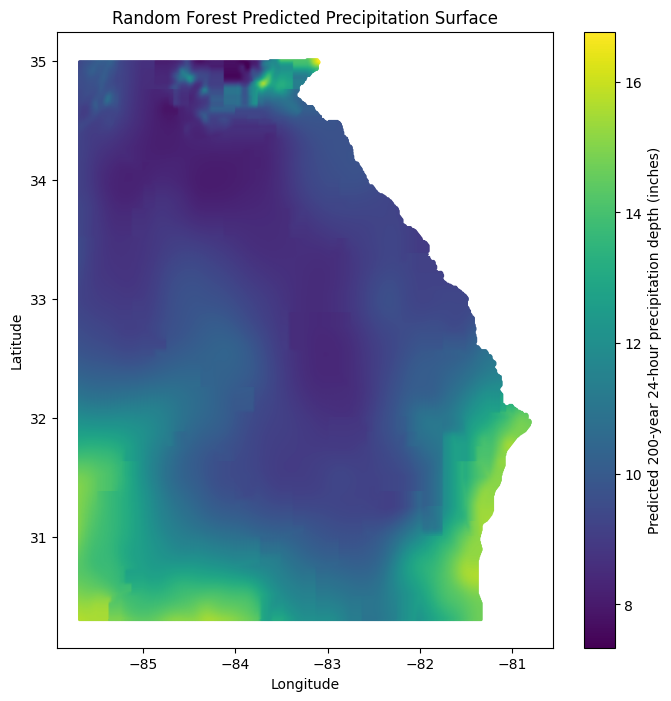

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ga["lon"],
    ga["lat"],
    c=ga["rf_best_prediction_in"],
    s=1
)

plt.colorbar(label="Predicted 200-year 24-hour precipitation depth (inches)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Forest Predicted Precipitation Surface")
plt.show()

In [ ]:
ga.to_csv("georgia_200yr_24hr_precip_with_predictions.csv", index=False)
files.download("georgia_200yr_24hr_precip_with_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

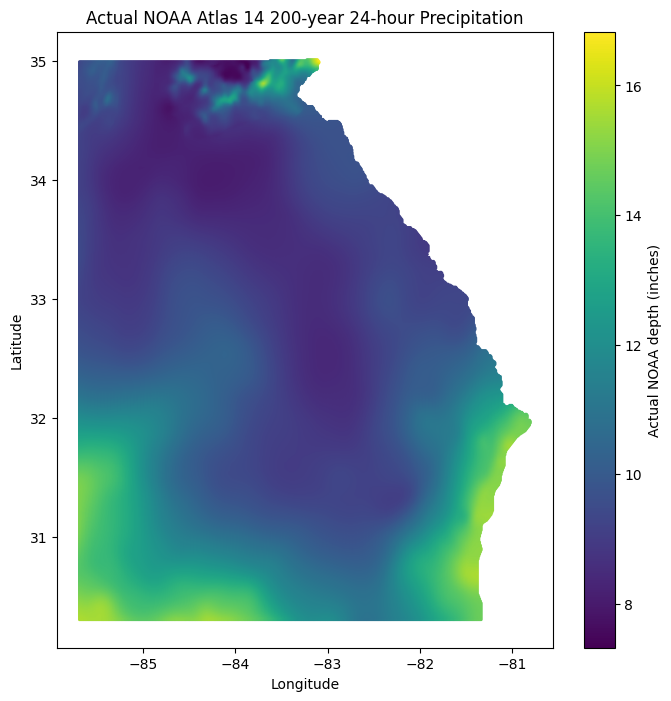

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ga["lon"],
    ga["lat"],
    c=ga["precip_depth_in"],
    s=1
)

plt.colorbar(label="Actual NOAA depth (inches)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Actual NOAA Atlas 14 200-year 24-hour Precipitation")
plt.show()

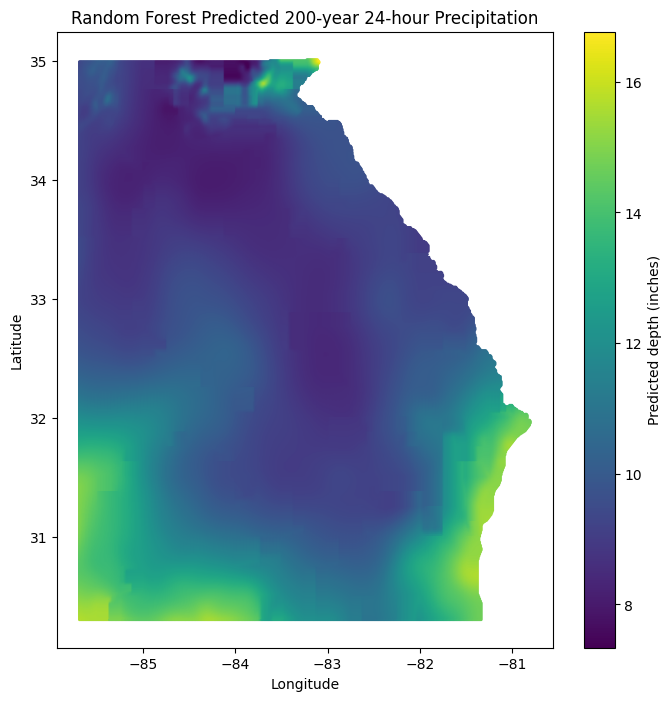

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ga["lon"],
    ga["lat"],
    c=ga["rf_best_prediction_in"],
    s=1
)

plt.colorbar(label="Predicted depth (inches)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Forest Predicted 200-year 24-hour Precipitation")
plt.show()

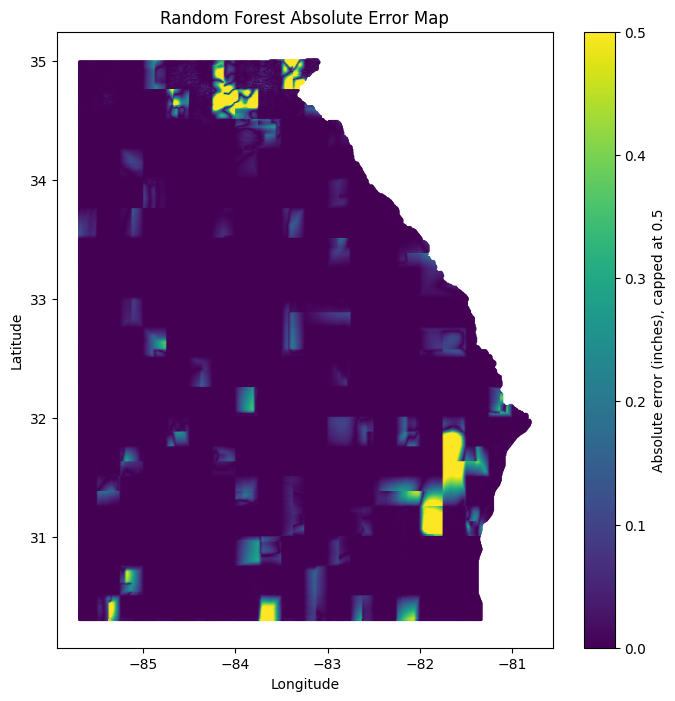

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(
    ga["lon"],
    ga["lat"],
    c=ga["rf_best_abs_error_in"],
    s=1,
    vmin=0,
    vmax=0.5
)

plt.colorbar(label="Absolute error (inches), capped at 0.5")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Random Forest Absolute Error Map")
plt.show()

In [ ]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Random Forest + Elevation",
        "XGBoost + Elevation"
    ],
    "Features": [
        "Latitude, Longitude",
        "Latitude, Longitude, Elevation",
        "Latitude, Longitude, Elevation"
    ],
    "Validation Method": [
        "Spatial Block Validation",
        "Spatial Block Validation",
        "Spatial Block Validation"
    ],
    "MAE_inches": [
        mae_block,
        mae_elev,
        mae_xgb
    ],
    "RMSE_inches": [
        rmse_block,
        rmse_elev,
        rmse_xgb
    ],
    "R2": [
        r2_block,
        r2_elev,
        r2_xgb
    ]
})

final_comparison

,Model,Features,Validation Method,MAE_inches,RMSE_inches,R2
0,Random Forest,"Latitude, Longitude",Spatial Block Validation,0.121051,0.255929,0.978479
1,Random Forest + Elevation,"Latitude, Longitude, Elevation",Spatial Block Validation,0.132106,0.282210,0.973832
2,XGBoost + Elevation,"Latitude, Longitude, Elevation",Spatial Block Validation,0.206955,0.365506,0.956104


In [ ]:
final_comparison.to_csv("final_model_comparison.csv", index=False)
files.download("final_model_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Baseline Model Conclusion

The best-performing model was the Random Forest Regressor using latitude and longitude as input features. Under spatial block validation, the model achieved an MAE of 0.121 inches, RMSE of 0.256 inches, and R² of 0.978 for estimating NOAA Atlas 14 200-year, 24-hour precipitation depth across Georgia.

Adding USGS DEM elevation as a feature did not improve performance. The Random Forest model with elevation achieved an RMSE of 0.282 inches, while XGBoost with elevation achieved an RMSE of 0.366 inches. This suggests that the NOAA Atlas 14 precipitation surface is strongly explained by spatial location alone for this first target grid, while raw elevation may need additional preprocessing or transformation to become useful.

The largest errors appear in northern Georgia and southeast/coastal Georgia, which may indicate areas where terrain, coastal influence, or additional climate variables such as PRISM precipitation normals could improve future models.

## 5. Multi-Return-Period Modeling

In [ ]:
import requests
import re

metadata_url = "https://hdsc.nws.noaa.gov/pfds/meta/na14_vol9_se_grid_metadata.xml"

xml_text = requests.get(metadata_url).text

print(xml_text[:2000])

<?xml version="1.0" encoding="ISO-8859-1"?>
<metadata>
<idinfo>
<datsetid>gov.noaa.nws.ohd.hdsc: OHD-HDSC-NOAAAtlas14V9v2013-SE</datsetid>
<citation>
<citeinfo>
<origin>NOAA/NWS/Office of Hydrologic Development, Hydrometeorological Design Studies Center</origin>
<pubdate>20130415</pubdate>
<title>Precipitation Frequency for Southeastern states, USA - NOAA Atlas 14 Volume 9</title>
<geoform>raster digital data</geoform>
<serinfo>
<sername>NOAA Atlas 14</sername>
<issue>Volume 9</issue>
</serinfo>
<pubinfo>
<pubplace>Silver Spring, MD, USA</pubplace>
<publish>NOAA/NWS/Office of Hydrologic Development, Hydrometeorological Design Studies Center</publish>
</pubinfo>
<onlink>./pfds_gis.html</onlink>
<onlink>./</onlink>
<onlink>http://www.nws.noaa.gov/ohd/hdsc/index.html</onlink>
</citeinfo>
</citation>
<descript>
<abstract>This GIS grid atlas contains precipitation frequency estimates for Southeastern states based on precipitation data collected between 1840-2013. This atlas supersedes infor

In [ ]:
links = re.findall(r"https?://[^\s<>]+", xml_text)

for link in links:
    print(link)

http://www.nws.noaa.gov/ohd/hdsc/index.html
http://lwf.ncdc.noaa.gov/oa/ncdc.html
http://www.climate.gov/#dataServices,20101231
http://cdo.ncdc.noaa.gov/
http://www.climate.gov/#dataServices,
http://lwf.ncdc.noaa.gov/oa/ncdc.html
http://www.climate.gov/#dataServices,
http://fawn.ifas.ufl.edu/
http://fawn.ifas.ufl.edu/,
http://mrcc.isws.illinois.edu/prod_serv/prodserv.htm.
http://weather.gfc.state.ga.us/climate/climate.aspx
http://weather.gfc.state.ga.us/climate/climate.aspx.
http://www.wcc.nrcs.usda.gov/scan/
http://www.wcc.nrcs.usda.gov/scan/.
http://www.nwfwmd.state.fl.us/pubsdata/hydrologicdata.html
http://www.nwfwmd.state.fl.us/pubsdata/hydrologicdata.html.
http://www.sfwmd.gov/
http://www.sfwmd.gov/portal/page/portal/pg_grp_sfwmd_era/pg_sfwmd_era_dbhydrobrowser.September
http://sjr.state.fl.us/
http://sjr.state.fl.us/.
http://www.swfwmd.state.fl.us/
http://www.swfwmd.state.fl.us/.November
http://trmm-fc.gsfc.nasa.gov/trmm_gv/data/data.html
https://nadp.isws.illinois.edu/
https://n

In [ ]:
import os
import urllib.request

os.makedirs("noaa_24hr_grids", exist_ok=True)

base_url = "https://hdsc.nws.noaa.gov/pub/hdsc/data/se/"

files_to_download = [
    "se2yr24ha.zip",
    "se5yr24ha.zip",
    "se10yr24ha.zip",
    "se25yr24ha.zip",
    "se50yr24ha.zip",
    "se100yr24ha.zip",
    "se200yr24ha.zip"
]

for filename in files_to_download:
    url = base_url + filename
    out_path = os.path.join("noaa_24hr_grids", filename)

    print("Downloading:", filename)
    urllib.request.urlretrieve(url, out_path)

print("Done.")
print(os.listdir("noaa_24hr_grids"))

Downloading: se2yr24ha.zip
Downloading: se5yr24ha.zip
Downloading: se10yr24ha.zip
Downloading: se25yr24ha.zip
Downloading: se50yr24ha.zip
Downloading: se100yr24ha.zip
Downloading: se200yr24ha.zip
Done.
['se10yr24ha.zip', 'se5yr24ha.zip', 'se25yr24ha.zip', 'se100yr24ha.zip', 'se200yr24ha.zip', 'se50yr24ha.zip', 'se2yr24ha.zip']


In [ ]:
import zipfile
import os
import glob

os.makedirs("noaa_24hr_unzipped", exist_ok=True)

zip_files = glob.glob("noaa_24hr_grids/*.zip")

for zip_file in zip_files:
    folder_name = os.path.basename(zip_file).replace(".zip", "")
    out_folder = os.path.join("noaa_24hr_unzipped", folder_name)
    os.makedirs(out_folder, exist_ok=True)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(out_folder)

print("Unzipped folders:")
print(os.listdir("noaa_24hr_unzipped"))

Unzipped folders:
['se25yr24ha', 'se50yr24ha', 'se100yr24ha', 'se5yr24ha', 'se2yr24ha', 'se10yr24ha', 'se200yr24ha']


In [ ]:
asc_files = glob.glob("noaa_24hr_unzipped/**/*.asc", recursive=True)

print("Number of ASC files:", len(asc_files))
for f in asc_files:
    print(f)

Number of ASC files: 7
noaa_24hr_unzipped/se25yr24ha/se25yr24ha.asc
noaa_24hr_unzipped/se50yr24ha/se50yr24ha.asc
noaa_24hr_unzipped/se100yr24ha/se100yr24ha.asc
noaa_24hr_unzipped/se5yr24ha/se5yr24ha.asc
noaa_24hr_unzipped/se2yr24ha/se2yr24ha.asc
noaa_24hr_unzipped/se10yr24ha/se10yr24ha.asc
noaa_24hr_unzipped/se200yr24ha/se200yr24ha.asc


In [ ]:
import re
import numpy as np
import pandas as pd

def asc_to_dataframe(asc_path):
    # Extract return period from filename, like se25yr24ha.asc -> 25
    match = re.search(r"se(\d+)yr24ha", asc_path)
    return_period = int(match.group(1))

    # Read header
    header = {}
    with open(asc_path, "r") as f:
        for _ in range(6):
            key, value = f.readline().split()
            header[key.lower()] = float(value)

    nrows = int(header["nrows"])
    xllcorner = header["xllcorner"]
    yllcorner = header["yllcorner"]
    cellsize = header["cellsize"]
    nodata = header["nodata_value"]

    # Load grid
    grid = np.loadtxt(asc_path, skiprows=6)

    # Convert cells to coordinates
    rows, cols = np.indices(grid.shape)
    lon = xllcorner + cols * cellsize + cellsize / 2
    lat = yllcorner + (nrows - rows - 1) * cellsize + cellsize / 2

    # Build dataframe
    temp = pd.DataFrame({
        "lat": lat.ravel(),
        "lon": lon.ravel(),
        "return_period": return_period,
        "precip_depth": grid.ravel()
    })

    # Remove no-data and convert to inches
    temp = temp[temp["precip_depth"] != nodata].copy()
    temp["precip_depth_in"] = temp["precip_depth"] / 1000

    # Rough Georgia filter
    temp = temp[
        (temp["lat"] >= 30.3) & (temp["lat"] <= 35.1) &
        (temp["lon"] >= -85.7) & (temp["lon"] <= -80.7)
    ].copy()

    return temp


all_dfs = []

for asc_file in asc_files:
    print("Processing:", asc_file)
    temp_df = asc_to_dataframe(asc_file)
    all_dfs.append(temp_df)

multi_rp = pd.concat(all_dfs, ignore_index=True)

print("Combined dataset shape:", multi_rp.shape)
display(multi_rp.head())
display(multi_rp["return_period"].value_counts().sort_index())
display(multi_rp.describe())

Processing: noaa_24hr_unzipped/se25yr24ha/se25yr24ha.asc
Processing: noaa_24hr_unzipped/se50yr24ha/se50yr24ha.asc
Processing: noaa_24hr_unzipped/se100yr24ha/se100yr24ha.asc
Processing: noaa_24hr_unzipped/se5yr24ha/se5yr24ha.asc
Processing: noaa_24hr_unzipped/se2yr24ha/se2yr24ha.asc
Processing: noaa_24hr_unzipped/se10yr24ha/se10yr24ha.asc
Processing: noaa_24hr_unzipped/se200yr24ha/se200yr24ha.asc
Combined dataset shape: (1860320, 5)


,lat,lon,return_period,precip_depth,precip_depth_in
0,35.007911,-83.225435,25,9389.0,9.389
1,35.007911,-83.217101,25,9415.0,9.415
2,35.007911,-83.208769,25,9456.0,9.456
3,35.007911,-83.200435,25,9515.0,9.515
4,35.007911,-83.192103,25,9588.0,9.588


,count
return_period,
2,265760
5,265760
10,265760
25,265760
50,265760
100,265760
200,265760


,lat,lon,return_period,precip_depth,precip_depth_in
count,1.860320e+06,1.860320e+06,1.860320e+06,1.860320e+06,1.860320e+06
mean,3.243391e+01,-8.366120e+01,5.600000e+01,7.034501e+03,7.034501e+00
std,1.280695e+00,1.235537e+00,6.687090e+01,2.359155e+03,2.359155e+00
min,3.030810e+01,-8.569200e+01,2.000000e+00,3.202000e+03,3.202000e+00
25%,3.135806e+01,-8.470871e+01,5.000000e+00,5.112000e+03,5.112000e+00
50%,3.234968e+01,-8.372541e+01,2.500000e+01,6.816000e+03,6.816000e+00
75%,3.344964e+01,-8.268379e+01,1.000000e+02,8.554000e+03,8.554000e+00
max,3.500791e+01,-8.080053e+01,2.000000e+02,1.682900e+04,1.682900e+01


In [ ]:
multi_rp.to_csv("georgia_24hr_multi_return_period_precip.csv", index=False)
files.download("georgia_24hr_multi_return_period_precip.csv")

NameError: name 'files' is not defined

In [ ]:
from google.colab import files

multi_rp.to_csv("georgia_24hr_multi_return_period_precip.csv", index=False)
files.download("georgia_24hr_multi_return_period_precip.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create spatial blocks
multi_rp["lat_block"] = (multi_rp["lat"] // 0.25).astype(int)
multi_rp["lon_block"] = (multi_rp["lon"] // 0.25).astype(int)
multi_rp["spatial_block"] = multi_rp["lat_block"].astype(str) + "_" + multi_rp["lon_block"].astype(str)

# Inputs and target
X_multi = multi_rp[["lat", "lon", "return_period"]]
y_multi = multi_rp["precip_depth_in"]
groups_multi = multi_rp["spatial_block"]

# Spatial block split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_multi, y_multi, groups_multi))

X_train_multi = X_multi.iloc[train_idx]
X_test_multi = X_multi.iloc[test_idx]
y_train_multi = y_multi.iloc[train_idx]
y_test_multi = y_multi.iloc[test_idx]

# Train Random Forest
rf_multi = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train_multi, y_train_multi)

# Predict
y_pred_multi = rf_multi.predict(X_test_multi)

# Evaluate
mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("Multi-return-period RF MAE:", mae_multi)
print("Multi-return-period RF RMSE:", rmse_multi)
print("Multi-return-period RF R²:", r2_multi)

KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create spatial blocks
multi_rp["lat_block"] = (multi_rp["lat"] // 0.25).astype(int)
multi_rp["lon_block"] = (multi_rp["lon"] // 0.25).astype(int)
multi_rp["spatial_block"] = multi_rp["lat_block"].astype(str) + "_" + multi_rp["lon_block"].astype(str)

# Sample 150,000 rows to make training faster
multi_sample = multi_rp.sample(n=150000, random_state=42)

X_multi = multi_sample[["lat", "lon", "return_period"]]
y_multi = multi_sample["precip_depth_in"]
groups_multi = multi_sample["spatial_block"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_multi, y_multi, groups_multi))

X_train_multi = X_multi.iloc[train_idx]
X_test_multi = X_multi.iloc[test_idx]
y_train_multi = y_multi.iloc[train_idx]
y_test_multi = y_multi.iloc[test_idx]

rf_multi = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_multi.fit(X_train_multi, y_train_multi)

y_pred_multi = rf_multi.predict(X_test_multi)

mae_multi = mean_absolute_error(y_test_multi, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_multi, y_pred_multi))
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("Multi-return-period RF MAE:", mae_multi)
print("Multi-return-period RF RMSE:", rmse_multi)
print("Multi-return-period RF R²:", r2_multi)

Multi-return-period RF MAE: 0.08977715074696102
Multi-return-period RF RMSE: 0.19797944992436475
Multi-return-period RF R²: 0.9926998009845178


In [ ]:
multi_results = X_test_multi.copy()
multi_results["actual_depth_in"] = y_test_multi
multi_results["predicted_depth_in"] = y_pred_multi
multi_results["error_in"] = multi_results["predicted_depth_in"] - multi_results["actual_depth_in"]
multi_results["absolute_error_in"] = abs(multi_results["error_in"])

multi_results.head()

,lat,lon,return_period,actual_depth_in,predicted_depth_in,error_in,absolute_error_in
293701,34.257941,-83.817078,50,6.818,6.835115,0.017115,0.017115
521283,30.466427,-83.683750,50,10.097,10.169120,0.072120,0.072120
735153,31.291393,-83.750414,100,8.650,8.635642,-0.014358,0.014358
1722351,32.424681,-84.433719,200,10.367,10.319060,-0.047940,0.047940
1196287,32.341351,-84.275393,2,3.942,3.976460,0.034460,0.034460


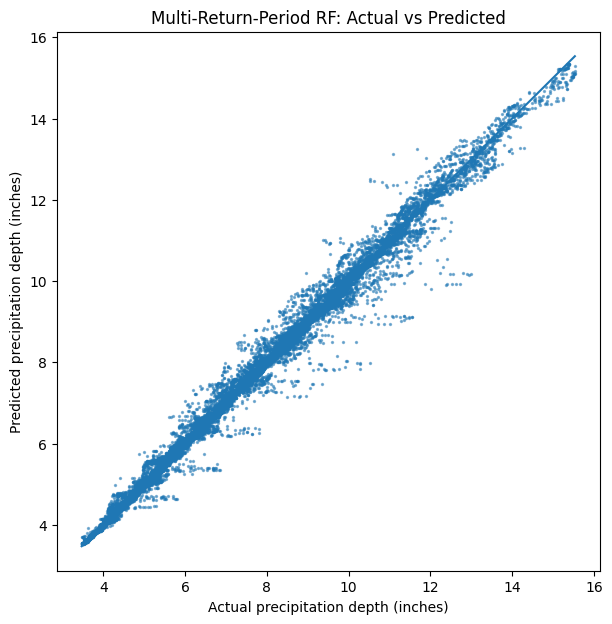

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test_multi, y_pred_multi, s=2, alpha=0.5)
plt.xlabel("Actual precipitation depth (inches)")
plt.ylabel("Predicted precipitation depth (inches)")
plt.title("Multi-Return-Period RF: Actual vs Predicted")

plt.plot(
    [y_test_multi.min(), y_test_multi.max()],
    [y_test_multi.min(), y_test_multi.max()]
)

plt.show()

In [ ]:
multi_model_metrics = pd.DataFrame({
    "Model": ["Random Forest Multi-Return-Period"],
    "Features": ["Latitude, Longitude, Return Period"],
    "Target": ["24-hour precipitation depth"],
    "Validation": ["Spatial block validation on 150,000-row sample"],
    "MAE_inches": [mae_multi],
    "RMSE_inches": [rmse_multi],
    "R2": [r2_multi]
})

multi_model_metrics

,Model,Features,Target,Validation,MAE_inches,RMSE_inches,R2
0,Random Forest Multi-Return-Period,"Latitude, Longitude, Return Period",24-hour precipitation depth,"Spatial block validation on 150,000-row sample",0.089777,0.197979,0.9927


In [ ]:
from google.colab import files

multi_results.to_csv("multi_return_period_predictions.csv", index=False)
multi_model_metrics.to_csv("multi_return_period_metrics.csv", index=False)

files.download("multi_return_period_predictions.csv")
files.download("multi_return_period_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Full PIDF Modeling

In [ ]:
import os
import urllib.request

os.makedirs("noaa_multi_duration_grids", exist_ok=True)

base_url = "https://hdsc.nws.noaa.gov/pub/hdsc/data/se/"

return_periods = [2, 5, 10, 25, 50, 100, 200]

# NOAA uses "60m" for the 1-hour duration
durations = {
    "60m": 1,
    "06h": 6,
    "12h": 12,
    "24h": 24
}

for rp in return_periods:
    for duration_code, duration_hr in durations.items():
        filename = f"se{rp}yr{duration_code}a.zip"
        url = base_url + filename
        output_path = os.path.join("noaa_multi_duration_grids", filename)

        print("Downloading:", filename)

        try:
            urllib.request.urlretrieve(url, output_path)
        except Exception as e:
            print("Failed:", filename, e)

print("Done.")
print(os.listdir("noaa_multi_duration_grids"))

Downloading: se2yr60ma.zip
Downloading: se2yr06ha.zip
Downloading: se2yr12ha.zip
Downloading: se2yr24ha.zip
Downloading: se5yr60ma.zip
Downloading: se5yr06ha.zip
Downloading: se5yr12ha.zip
Downloading: se5yr24ha.zip
Downloading: se10yr60ma.zip
Downloading: se10yr06ha.zip
Downloading: se10yr12ha.zip
Downloading: se10yr24ha.zip
Downloading: se25yr60ma.zip
Downloading: se25yr06ha.zip
Downloading: se25yr12ha.zip
Downloading: se25yr24ha.zip
Downloading: se50yr60ma.zip
Downloading: se50yr06ha.zip
Downloading: se50yr12ha.zip
Downloading: se50yr24ha.zip
Downloading: se100yr60ma.zip
Downloading: se100yr06ha.zip
Downloading: se100yr12ha.zip
Downloading: se100yr24ha.zip
Downloading: se200yr60ma.zip
Downloading: se200yr06ha.zip
Downloading: se200yr12ha.zip
Downloading: se200yr24ha.zip
Done.
['se25yr12ha.zip', 'se100yr24ha.zip', 'se10yr06ha.zip', 'se5yr12ha.zip', 'se5yr06ha.zip', 'se25yr06ha.zip', 'se200yr60ma.zip', 'se100yr12ha.zip', 'se10yr60ma.zip', 'se5yr24ha.zip', 'se10yr24ha.zip', 'se2yr60ma.

In [ ]:
base_url = "https://hdsc.nws.noaa.gov/pub/hdsc/data/se/"

return_periods = [2, 5, 10, 25, 50, 100, 200]

for rp in return_periods:
    filename = f"se{rp}yr60ma.zip"
    url = base_url + filename
    out_path = os.path.join("noaa_multi_duration_grids", filename)

    try:
        print("Downloading:", filename)
        urllib.request.urlretrieve(url, out_path)
    except Exception as e:
        print("Failed:", filename, e)

print("Done.")
print(os.listdir("noaa_multi_duration_grids"))

Downloading: se2yr60ma.zip
Downloading: se5yr60ma.zip
Downloading: se10yr60ma.zip
Downloading: se25yr60ma.zip
Downloading: se50yr60ma.zip
Downloading: se100yr60ma.zip
Downloading: se200yr60ma.zip
Done.
['se25yr12ha.zip', 'se100yr24ha.zip', 'se10yr06ha.zip', 'se5yr12ha.zip', 'se5yr06ha.zip', 'se25yr06ha.zip', 'se200yr60ma.zip', 'se100yr12ha.zip', 'se10yr60ma.zip', 'se5yr24ha.zip', 'se10yr24ha.zip', 'se2yr60ma.zip', 'se50yr12ha.zip', 'se2yr12ha.zip', 'se25yr60ma.zip', 'se200yr06ha.zip', 'se50yr06ha.zip', 'se5yr60ma.zip', 'se2yr06ha.zip', 'se50yr60ma.zip', 'se100yr06ha.zip', 'se50yr24ha.zip', 'se10yr12ha.zip', 'se25yr24ha.zip', 'se100yr60ma.zip', 'se2yr24ha.zip', 'se200yr12ha.zip', 'se200yr24ha.zip']


In [ ]:
import glob
import os

zip_files = glob.glob("noaa_multi_duration_grids/*.zip")

print("Number of ZIP files:", len(zip_files))
for f in sorted(zip_files):
    print(os.path.basename(f))

Number of ZIP files: 28
se100yr06ha.zip
se100yr12ha.zip
se100yr24ha.zip
se100yr60ma.zip
se10yr06ha.zip
se10yr12ha.zip
se10yr24ha.zip
se10yr60ma.zip
se200yr06ha.zip
se200yr12ha.zip
se200yr24ha.zip
se200yr60ma.zip
se25yr06ha.zip
se25yr12ha.zip
se25yr24ha.zip
se25yr60ma.zip
se2yr06ha.zip
se2yr12ha.zip
se2yr24ha.zip
se2yr60ma.zip
se50yr06ha.zip
se50yr12ha.zip
se50yr24ha.zip
se50yr60ma.zip
se5yr06ha.zip
se5yr12ha.zip
se5yr24ha.zip
se5yr60ma.zip


In [ ]:
import zipfile
import os
import glob

os.makedirs("noaa_pidf_unzipped", exist_ok=True)

zip_files = glob.glob("noaa_multi_duration_grids/*.zip")

for zip_file in zip_files:
    folder_name = os.path.basename(zip_file).replace(".zip", "")
    out_folder = os.path.join("noaa_pidf_unzipped", folder_name)
    os.makedirs(out_folder, exist_ok=True)

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(out_folder)

asc_files_pidf = glob.glob("noaa_pidf_unzipped/**/*.asc", recursive=True)

print("Number of ASC files:", len(asc_files_pidf))
for f in sorted(asc_files_pidf):
    print(f)

Number of ASC files: 28
noaa_pidf_unzipped/se100yr06ha/se100yr06ha.asc
noaa_pidf_unzipped/se100yr12ha/se100yr12ha.asc
noaa_pidf_unzipped/se100yr24ha/se100yr24ha.asc
noaa_pidf_unzipped/se100yr60ma/se100yr60ma.asc
noaa_pidf_unzipped/se10yr06ha/se10yr06ha.asc
noaa_pidf_unzipped/se10yr12ha/se10yr12ha.asc
noaa_pidf_unzipped/se10yr24ha/se10yr24ha.asc
noaa_pidf_unzipped/se10yr60ma/se10yr60ma.asc
noaa_pidf_unzipped/se200yr06ha/se200yr06ha.asc
noaa_pidf_unzipped/se200yr12ha/se200yr12ha.asc
noaa_pidf_unzipped/se200yr24ha/se200yr24ha.asc
noaa_pidf_unzipped/se200yr60ma/se200yr60ma.asc
noaa_pidf_unzipped/se25yr06ha/se25yr06ha.asc
noaa_pidf_unzipped/se25yr12ha/se25yr12ha.asc
noaa_pidf_unzipped/se25yr24ha/se25yr24ha.asc
noaa_pidf_unzipped/se25yr60ma/se25yr60ma.asc
noaa_pidf_unzipped/se2yr06ha/se2yr06ha.asc
noaa_pidf_unzipped/se2yr12ha/se2yr12ha.asc
noaa_pidf_unzipped/se2yr24ha/se2yr24ha.asc
noaa_pidf_unzipped/se2yr60ma/se2yr60ma.asc
noaa_pidf_unzipped/se50yr06ha/se50yr06ha.asc
noaa_pidf_unzipped/se50

In [ ]:
import re
import numpy as np
import pandas as pd

def parse_pidf_filename(path):
    name = os.path.basename(path)

    rp_match = re.search(r"se(\d+)yr", name)
    return_period = int(rp_match.group(1))

    if "60m" in name:
        duration_hr = 1
    elif "06h" in name:
        duration_hr = 6
    elif "12h" in name:
        duration_hr = 12
    elif "24h" in name:
        duration_hr = 24
    else:
        raise ValueError(f"Unknown duration in filename: {name}")

    return return_period, duration_hr


def asc_to_pidf_dataframe(asc_path):
    return_period, duration_hr = parse_pidf_filename(asc_path)

    header = {}
    with open(asc_path, "r") as f:
        for _ in range(6):
            key, value = f.readline().split()
            header[key.lower()] = float(value)

    nrows = int(header["nrows"])
    xllcorner = header["xllcorner"]
    yllcorner = header["yllcorner"]
    cellsize = header["cellsize"]
    nodata = header["nodata_value"]

    grid = np.loadtxt(asc_path, skiprows=6)

    rows, cols = np.indices(grid.shape)

    lon = xllcorner + cols * cellsize + cellsize / 2
    lat = yllcorner + (nrows - rows - 1) * cellsize + cellsize / 2

    temp = pd.DataFrame({
        "lat": lat.ravel(),
        "lon": lon.ravel(),
        "duration_hr": duration_hr,
        "return_period": return_period,
        "precip_depth": grid.ravel()
    })

    temp = temp[temp["precip_depth"] != nodata].copy()
    temp["precip_depth_in"] = temp["precip_depth"] / 1000

    temp = temp[
        (temp["lat"] >= 30.3) & (temp["lat"] <= 35.1) &
        (temp["lon"] >= -85.7) & (temp["lon"] <= -80.7)
    ].copy()

    return temp


all_pidf_dfs = []

for asc_file in asc_files_pidf:
    print("Processing:", asc_file)
    all_pidf_dfs.append(asc_to_pidf_dataframe(asc_file))

pidf = pd.concat(all_pidf_dfs, ignore_index=True)

print("PIDF dataset shape:", pidf.shape)
display(pidf.head())
display(pidf[["duration_hr", "return_period"]].value_counts().sort_index())
display(pidf.describe())

Processing: noaa_pidf_unzipped/se10yr12ha/se10yr12ha.asc
Processing: noaa_pidf_unzipped/se50yr24ha/se50yr24ha.asc
Processing: noaa_pidf_unzipped/se100yr24ha/se100yr24ha.asc
Processing: noaa_pidf_unzipped/se200yr12ha/se200yr12ha.asc
Processing: noaa_pidf_unzipped/se10yr06ha/se10yr06ha.asc
Processing: noaa_pidf_unzipped/se50yr60ma/se50yr60ma.asc
Processing: noaa_pidf_unzipped/se50yr12ha/se50yr12ha.asc
Processing: noaa_pidf_unzipped/se200yr60ma/se200yr60ma.asc
Processing: noaa_pidf_unzipped/se10yr24ha/se10yr24ha.asc
Processing: noaa_pidf_unzipped/se2yr06ha/se2yr06ha.asc
Processing: noaa_pidf_unzipped/se2yr12ha/se2yr12ha.asc
Processing: noaa_pidf_unzipped/se200yr24ha/se200yr24ha.asc
Processing: noaa_pidf_unzipped/se5yr12ha/se5yr12ha.asc
Processing: noaa_pidf_unzipped/se25yr12ha/se25yr12ha.asc
Processing: noaa_pidf_unzipped/se100yr60ma/se100yr60ma.asc
Processing: noaa_pidf_unzipped/se2yr60ma/se2yr60ma.asc
Processing: noaa_pidf_unzipped/se100yr06ha/se100yr06ha.asc
Processing: noaa_pidf_unzip

,lat,lon,duration_hr,return_period,precip_depth,precip_depth_in
0,35.007911,-83.225435,12,10,5966.0,5.966
1,35.007911,-83.217101,12,10,5974.0,5.974
2,35.007911,-83.208769,12,10,5991.0,5.991
3,35.007911,-83.200435,12,10,6019.0,6.019
4,35.007911,-83.192103,12,10,6055.0,6.055


duration_hr  return_period
1            2                265760
             5                265760
             10               265760
             25               265760
             50               265760
             100              265760
             200              265760
6            2                265760
             5                265760
             10               265760
             25               265760
             50               265760
             100              265760
             200              265760
12           2                265760
             5                265760
             10               265760
             25               265760
             50               265760
             100              265760
             200              265760
24           2                265760
             5                265760
             10               265760
             25               265760
             50               265760
             100              265760
             200              265760
Name: count, dtype: int64

,lat,lon,duration_hr,return_period,precip_depth,precip_depth_in
count,7.441280e+06,7.441280e+06,7.441280e+06,7.441280e+06,7.441280e+06,7.441280e+06
mean,3.243391e+01,-8.366120e+01,1.075000e+01,5.600000e+01,5.198589e+03,5.198589e+00
std,1.280694e+00,1.235537e+00,8.584143e+00,6.687088e+01,2.342368e+03,2.342368e+00
min,3.030810e+01,-8.569200e+01,1.000000e+00,2.000000e+00,1.218000e+03,1.218000e+00
25%,3.135806e+01,-8.470871e+01,4.750000e+00,5.000000e+00,3.418000e+03,3.418000e+00
50%,3.234968e+01,-8.372541e+01,9.000000e+00,2.500000e+01,4.707000e+03,4.707000e+00
75%,3.344964e+01,-8.268379e+01,1.500000e+01,1.000000e+02,6.701000e+03,6.701000e+00
max,3.500791e+01,-8.080053e+01,2.400000e+01,2.000000e+02,1.682900e+04,1.682900e+01


In [ ]:
# Keep only coordinates inside the official Georgia Census boundary

valid_ga_coords = pd.MultiIndex.from_frame(
    ga[["lat", "lon"]]
)

pidf_coords = pd.MultiIndex.from_frame(
    pidf[["lat", "lon"]]
)

pidf = pidf[pidf_coords.isin(valid_ga_coords)].copy()
pidf = pidf.reset_index(drop=True)

print("Official-boundary PIDF shape:", pidf.shape)

display(
    pidf.groupby(["duration_hr", "return_period"])
        .size()
        .rename("count")
)

display(pidf.describe())

Official-boundary PIDF shape: (5957336, 6)


duration_hr  return_period
1            2                212762
             5                212762
             10               212762
             25               212762
             50               212762
             100              212762
             200              212762
6            2                212762
             5                212762
             10               212762
             25               212762
             50               212762
             100              212762
             200              212762
12           2                212762
             5                212762
             10               212762
             25               212762
             50               212762
             100              212762
             200              212762
24           2                212762
             5                212762
             10               212762
             25               212762
             50               212762
             100              212762
             200              212762
Name: count, dtype: int64

,lat,lon,duration_hr,return_period,precip_depth,precip_depth_in
count,5.957336e+06,5.957336e+06,5.957336e+06,5.957336e+06,5.957336e+06,5.957336e+06
mean,3.264045e+01,-8.343046e+01,1.075000e+01,5.600000e+01,5.032353e+03,5.032353e+00
std,1.195372e+00,1.109448e+00,8.584143e+00,6.687088e+01,2.186529e+03,2.186529e+00
min,3.035810e+01,-8.560034e+01,1.000000e+00,2.000000e+00,1.218000e+03,1.218000e+00
25%,3.163305e+01,-8.435872e+01,4.750000e+00,5.000000e+00,3.353000e+03,3.353000e+00
50%,3.255801e+01,-8.350042e+01,9.000000e+00,2.500000e+01,4.588000e+03,4.588000e+00
75%,3.359963e+01,-8.255879e+01,1.500000e+01,1.000000e+02,6.485000e+03,6.485000e+00
max,3.499958e+01,-8.080053e+01,2.400000e+01,2.000000e+02,1.669000e+04,1.669000e+01


In [ ]:
from google.colab import files

pidf.to_csv("georgia_pidf_multi_duration_return_period.csv", index=False)
files.download("georgia_pidf_multi_duration_return_period.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create spatial blocks
pidf["lat_block"] = (pidf["lat"] // 0.25).astype(int)
pidf["lon_block"] = (pidf["lon"] // 0.25).astype(int)
pidf["spatial_block"] = pidf["lat_block"].astype(str) + "_" + pidf["lon_block"].astype(str)

# Sample for faster training
pidf_sample = pidf.sample(n=250000, random_state=42)

X_pidf = pidf_sample[["lat", "lon", "duration_hr", "return_period"]]
y_pidf = pidf_sample["precip_depth_in"]
groups_pidf = pidf_sample["spatial_block"]

# Spatial block split
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X_pidf, y_pidf, groups_pidf))

X_train_pidf = X_pidf.iloc[train_idx]
X_test_pidf = X_pidf.iloc[test_idx]
y_train_pidf = y_pidf.iloc[train_idx]
y_test_pidf = y_pidf.iloc[test_idx]

# Train model
rf_pidf = RandomForestRegressor(
    n_estimators=50,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

rf_pidf.fit(X_train_pidf, y_train_pidf)

# Predict
y_pred_pidf = rf_pidf.predict(X_test_pidf)

# Evaluate
mae_pidf = mean_absolute_error(y_test_pidf, y_pred_pidf)
rmse_pidf = np.sqrt(mean_squared_error(y_test_pidf, y_pred_pidf))
r2_pidf = r2_score(y_test_pidf, y_pred_pidf)

print("Full PIDF RF MAE:", mae_pidf)
print("Full PIDF RF RMSE:", rmse_pidf)
print("Full PIDF RF R²:", r2_pidf)

Full PIDF RF MAE: 0.06575968986647435
Full PIDF RF RMSE: 0.20451353960310295
Full PIDF RF R²: 0.9913424680862872


### Dataset and Spatial-Block Accounting

To make the validation design explicit, the cell below reports the number of observations and the number of unique 0.25° spatial blocks used by the full PIDF experiment. The held-out test set contains entire spatial blocks that are not used for training.


In [ ]:
# Dataset and spatial-block accounting requested for model documentation
train_groups_pidf = groups_pidf.iloc[train_idx]
test_groups_pidf = groups_pidf.iloc[test_idx]

print("Full official-boundary PIDF data points:", len(pidf))
print("Sampled data points:", len(pidf_sample))
print("Training data points:", len(X_train_pidf))
print("Test data points:", len(X_test_pidf))
print("Total unique spatial blocks:", pidf["spatial_block"].nunique())
print("Sample unique spatial blocks:", groups_pidf.nunique())
print("Training spatial blocks:", train_groups_pidf.nunique())
print("Test spatial blocks:", test_groups_pidf.nunique())
print("Shared train/test blocks:", len(set(train_groups_pidf) & set(test_groups_pidf)))


In [ ]:
pidf_metrics = pd.DataFrame({
    "Model": ["Random Forest Full PIDF"],
    "Features": ["Latitude, Longitude, Duration, Return Period"],
    "Target": ["Precipitation depth"],
    "Validation": ["Spatial block validation on 250,000-row sample"],
    "MAE_inches": [mae_pidf],
    "RMSE_inches": [rmse_pidf],
    "R2": [r2_pidf]
})

pidf_metrics

,Model,Features,Target,Validation,MAE_inches,RMSE_inches,R2
0,Random Forest Full PIDF,"Latitude, Longitude, Duration, Return Period",Precipitation depth,"Spatial block validation on 250,000-row sample",0.055178,0.119409,0.9973


In [ ]:
pidf_results = X_test_pidf.copy()
pidf_results["actual_depth_in"] = y_test_pidf
pidf_results["predicted_depth_in"] = y_pred_pidf
pidf_results["error_in"] = pidf_results["predicted_depth_in"] - pidf_results["actual_depth_in"]
pidf_results["absolute_error_in"] = abs(pidf_results["error_in"])

pidf_results.head()

,lat,lon,duration_hr,return_period,actual_depth_in,predicted_depth_in,error_in,absolute_error_in
1022734,30.949741,-82.858783,6,200,7.178,7.093200,-0.084800,0.084800
431379,31.866370,-82.858783,6,5,3.335,3.332025,-0.002975,0.002975
3495059,33.974619,-85.075361,1,5,1.868,1.876650,0.008650,0.008650
4462384,31.191397,-82.692123,1,2,1.908,1.892340,-0.015660,0.015660
7131961,30.999738,-83.908741,24,200,10.743,10.674600,-0.068400,0.068400


In [ ]:
from google.colab import files

pidf_metrics.to_csv("full_pidf_rf_metrics.csv", index=False)
pidf_results.to_csv("full_pidf_rf_predictions.csv", index=False)

files.download("full_pidf_rf_metrics.csv")
files.download("full_pidf_rf_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Location-Based IDF Analysis

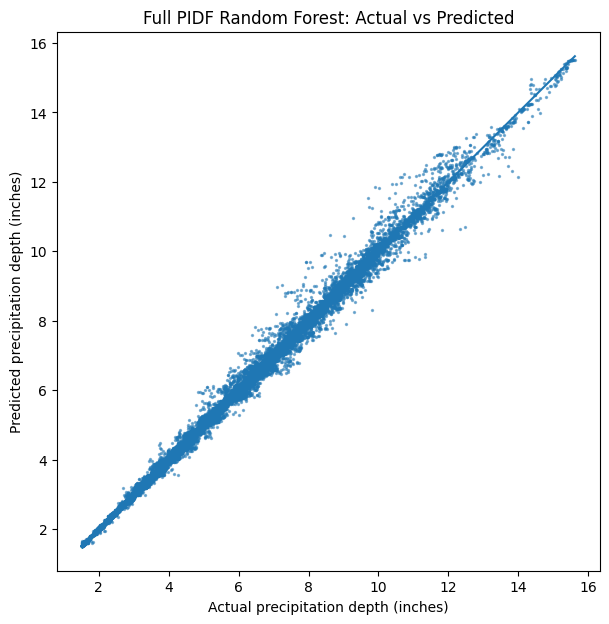

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test_pidf, y_pred_pidf, s=2, alpha=0.5)
plt.xlabel("Actual precipitation depth (inches)")
plt.ylabel("Predicted precipitation depth (inches)")
plt.title("Full PIDF Random Forest: Actual vs Predicted")

plt.plot(
    [y_test_pidf.min(), y_test_pidf.max()],
    [y_test_pidf.min(), y_test_pidf.max()]
)

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Monroe, GA coordinates from the reference project
monroe_lat = 33.7833
monroe_lon = -83.7167

return_periods = [2, 5, 10, 25, 50, 100, 200]
durations = [1, 6, 12, 24]

# Build prediction table for Monroe
monroe_rows = []

for rp in return_periods:
    for duration in durations:
        monroe_rows.append({
            "lat": monroe_lat,
            "lon": monroe_lon,
            "duration_hr": duration,
            "return_period": rp
        })

monroe_df = pd.DataFrame(monroe_rows)

# Predict precipitation depth
monroe_df["predicted_depth_in"] = rf_pidf.predict(
    monroe_df[["lat", "lon", "duration_hr", "return_period"]]
)

# Convert depth to intensity
monroe_df["predicted_intensity_in_per_hr"] = (
    monroe_df["predicted_depth_in"] / monroe_df["duration_hr"]
)

monroe_df

,lat,lon,duration_hr,return_period,predicted_depth_in,predicted_intensity_in_per_hr
0,33.7833,-83.7167,1,2,1.530420,1.530420
1,33.7833,-83.7167,6,2,2.534343,0.422391
2,33.7833,-83.7167,12,2,3.098849,0.258237
3,33.7833,-83.7167,24,2,3.719900,0.154996
4,33.7833,-83.7167,1,5,1.857284,1.857284
5,33.7833,-83.7167,6,5,3.058330,0.509722
6,33.7833,-83.7167,12,5,3.732207,0.311017
7,33.7833,-83.7167,24,5,4.487449,0.186977
8,33.7833,-83.7167,1,10,2.131381,2.131381
9,33.7833,-83.7167,6,10,3.526947,0.587824


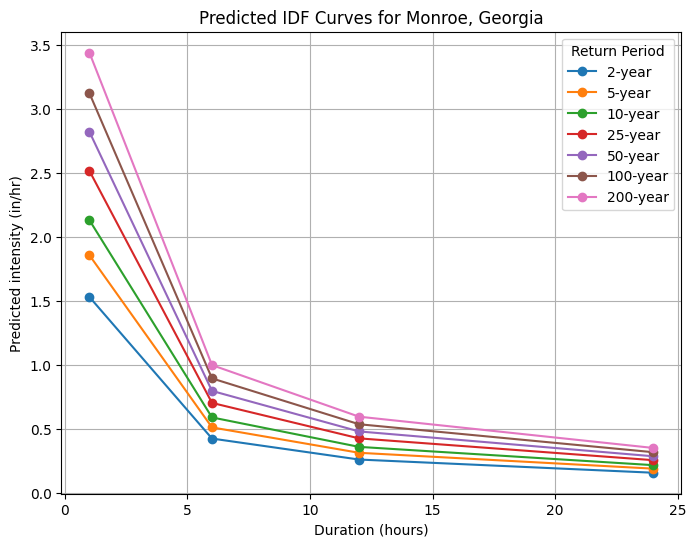

In [ ]:
plt.figure(figsize=(8, 6))

for rp in return_periods:
    subset = monroe_df[monroe_df["return_period"] == rp]
    plt.plot(
        subset["duration_hr"],
        subset["predicted_intensity_in_per_hr"],
        marker="o",
        label=f"{rp}-year"
    )

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("Predicted IDF Curves for Monroe, Georgia")
plt.legend(title="Return Period")
plt.grid(True)
plt.show()

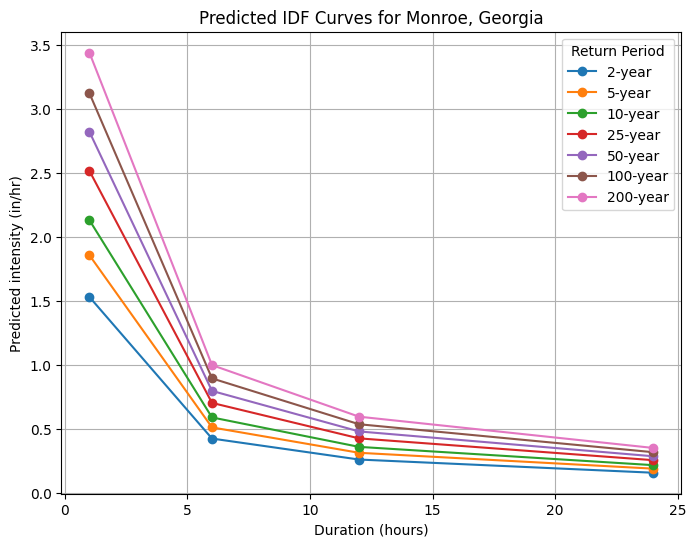

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8, 6))

for rp in return_periods:
    subset = monroe_df[monroe_df["return_period"] == rp]
    plt.plot(
        subset["duration_hr"],
        subset["predicted_intensity_in_per_hr"],
        marker="o",
        label=f"{rp}-year"
    )

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("Predicted IDF Curves for Monroe, Georgia")
plt.legend(title="Return Period")
plt.grid(True)

plt.savefig("monroe_predicted_idf_curve.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("monroe_predicted_idf_curve.png")

In [ ]:
monroe_df.to_csv("monroe_predicted_idf_values.csv", index=False)
files.download("monroe_predicted_idf_values.csv")

monroe_df

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,lat,lon,duration_hr,return_period,predicted_depth_in,predicted_intensity_in_per_hr
0,33.7833,-83.7167,1,2,1.530420,1.530420
1,33.7833,-83.7167,6,2,2.534343,0.422391
2,33.7833,-83.7167,12,2,3.098849,0.258237
3,33.7833,-83.7167,24,2,3.719900,0.154996
4,33.7833,-83.7167,1,5,1.857284,1.857284
5,33.7833,-83.7167,6,5,3.058330,0.509722
6,33.7833,-83.7167,12,5,3.732207,0.311017
7,33.7833,-83.7167,24,5,4.487449,0.186977
8,33.7833,-83.7167,1,10,2.131381,2.131381
9,33.7833,-83.7167,6,10,3.526947,0.587824


In [ ]:
monroe_df["predicted_intensity_in_per_hr"] = (
    monroe_df["predicted_depth_in"] / monroe_df["duration_hr"]
)

monroe_df

,lat,lon,duration_hr,return_period,predicted_depth_in,predicted_intensity_in_per_hr
0,33.7833,-83.7167,1,2,1.530420,1.530420
1,33.7833,-83.7167,6,2,2.534343,0.422391
2,33.7833,-83.7167,12,2,3.098849,0.258237
3,33.7833,-83.7167,24,2,3.719900,0.154996
4,33.7833,-83.7167,1,5,1.857284,1.857284
5,33.7833,-83.7167,6,5,3.058330,0.509722
6,33.7833,-83.7167,12,5,3.732207,0.311017
7,33.7833,-83.7167,24,5,4.487449,0.186977
8,33.7833,-83.7167,1,10,2.131381,2.131381
9,33.7833,-83.7167,6,10,3.526947,0.587824


In [ ]:
from google.colab import files

monroe_df.to_csv("monroe_predicted_pidf_idf_values.csv", index=False)
files.download("monroe_predicted_pidf_idf_values.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Atlanta, GA approximate coordinates
atlanta_lat = 33.7490
atlanta_lon = -84.3880

return_periods = [2, 5, 10, 25, 50, 100, 200]
durations = [1, 6, 12, 24]

atlanta_rows = []

for rp in return_periods:
    for duration in durations:
        atlanta_rows.append({
            "lat": atlanta_lat,
            "lon": atlanta_lon,
            "duration_hr": duration,
            "return_period": rp
        })

atlanta_df = pd.DataFrame(atlanta_rows)

atlanta_df["predicted_depth_in"] = rf_pidf.predict(
    atlanta_df[["lat", "lon", "duration_hr", "return_period"]]
)

atlanta_df["predicted_intensity_in_per_hr"] = (
    atlanta_df["predicted_depth_in"] / atlanta_df["duration_hr"]
)

atlanta_df

,lat,lon,duration_hr,return_period,predicted_depth_in,predicted_intensity_in_per_hr
0,33.749,-84.388,1,2,1.519080,1.519080
1,33.749,-84.388,6,2,2.484010,0.414002
2,33.749,-84.388,12,2,3.049245,0.254104
3,33.749,-84.388,24,2,3.697749,0.154073
4,33.749,-84.388,1,5,1.849700,1.849700
5,33.749,-84.388,6,5,2.977628,0.496271
6,33.749,-84.388,12,5,3.608346,0.300696
7,33.749,-84.388,24,5,4.411859,0.183827
8,33.749,-84.388,1,10,2.138207,2.138207
9,33.749,-84.388,6,10,3.433602,0.572267


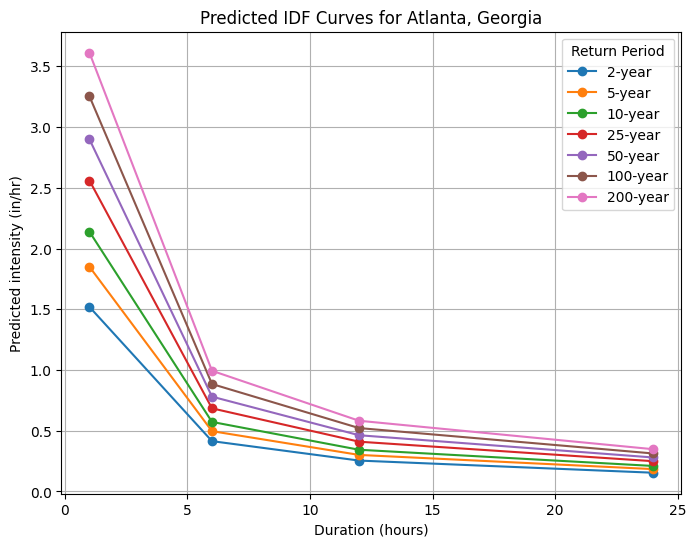

In [ ]:
plt.figure(figsize=(8, 6))

for rp in return_periods:
    subset = atlanta_df[atlanta_df["return_period"] == rp]
    plt.plot(
        subset["duration_hr"],
        subset["predicted_intensity_in_per_hr"],
        marker="o",
        label=f"{rp}-year"
    )

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("Predicted IDF Curves for Atlanta, Georgia")
plt.legend(title="Return Period")
plt.grid(True)
plt.show()

In [ ]:
from google.colab import files

atlanta_df.to_csv("atlanta_predicted_pidf_idf_values.csv", index=False)
files.download("atlanta_predicted_pidf_idf_values.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

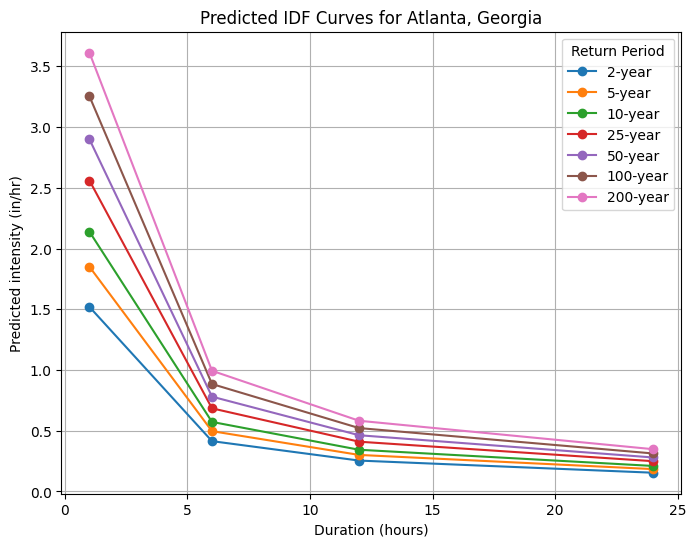

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8, 6))

for rp in return_periods:
    subset = atlanta_df[atlanta_df["return_period"] == rp]
    plt.plot(
        subset["duration_hr"],
        subset["predicted_intensity_in_per_hr"],
        marker="o",
        label=f"{rp}-year"
    )

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("Predicted IDF Curves for Atlanta, Georgia")
plt.legend(title="Return Period")
plt.grid(True)

plt.savefig("atlanta_predicted_idf_curve.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("atlanta_predicted_idf_curve.png")

In [ ]:
plt.savefig("atlanta_predicted_idf_curve.png", dpi=300, bbox_inches="tight")
files.download("atlanta_predicted_idf_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

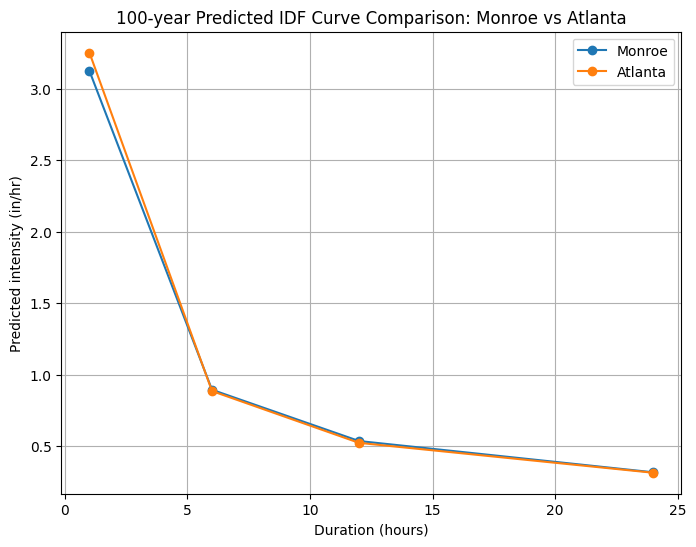

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8, 6))

# Pick one return period to compare
compare_rp = 100

monroe_100 = monroe_df[monroe_df["return_period"] == compare_rp]
atlanta_100 = atlanta_df[atlanta_df["return_period"] == compare_rp]

plt.plot(
    monroe_100["duration_hr"],
    monroe_100["predicted_intensity_in_per_hr"],
    marker="o",
    label="Monroe"
)

plt.plot(
    atlanta_100["duration_hr"],
    atlanta_100["predicted_intensity_in_per_hr"],
    marker="o",
    label="Atlanta"
)

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("100-year Predicted IDF Curve Comparison: Monroe vs Atlanta")
plt.legend()
plt.grid(True)

plt.savefig("monroe_vs_atlanta_100yr_idf_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("monroe_vs_atlanta_100yr_idf_comparison.png")

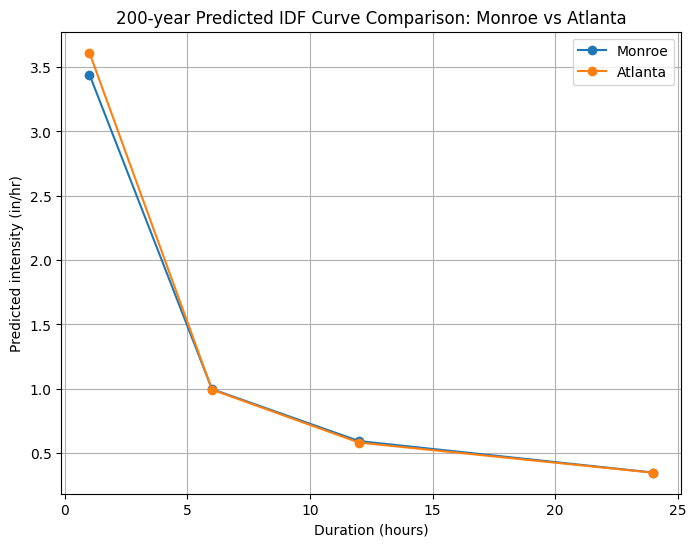

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
plt.figure(figsize=(8, 6))

compare_rp = 200

monroe_200 = monroe_df[monroe_df["return_period"] == compare_rp]
atlanta_200 = atlanta_df[atlanta_df["return_period"] == compare_rp]

plt.plot(
    monroe_200["duration_hr"],
    monroe_200["predicted_intensity_in_per_hr"],
    marker="o",
    label="Monroe"
)

plt.plot(
    atlanta_200["duration_hr"],
    atlanta_200["predicted_intensity_in_per_hr"],
    marker="o",
    label="Atlanta"
)

plt.xlabel("Duration (hours)")
plt.ylabel("Predicted intensity (in/hr)")
plt.title("200-year Predicted IDF Curve Comparison: Monroe vs Atlanta")
plt.legend()
plt.grid(True)

plt.savefig("monroe_vs_atlanta_200yr_idf_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

files.download("monroe_vs_atlanta_200yr_idf_comparison.png")

In [ ]:
compare_rp = 200

monroe_compare = monroe_df[monroe_df["return_period"] == compare_rp].copy()
atlanta_compare = atlanta_df[atlanta_df["return_period"] == compare_rp].copy()

comparison_200 = pd.DataFrame({
    "duration_hr": monroe_compare["duration_hr"].values,
    "monroe_depth_in": monroe_compare["predicted_depth_in"].values,
    "monroe_intensity_in_per_hr": monroe_compare["predicted_intensity_in_per_hr"].values,
    "atlanta_depth_in": atlanta_compare["predicted_depth_in"].values,
    "atlanta_intensity_in_per_hr": atlanta_compare["predicted_intensity_in_per_hr"].values
})

comparison_200["depth_difference_atl_minus_monroe"] = (
    comparison_200["atlanta_depth_in"] - comparison_200["monroe_depth_in"]
)

comparison_200["intensity_difference_atl_minus_monroe"] = (
    comparison_200["atlanta_intensity_in_per_hr"] - comparison_200["monroe_intensity_in_per_hr"]
)

comparison_200

,duration_hr,monroe_depth_in,monroe_intensity_in_per_hr,atlanta_depth_in,atlanta_intensity_in_per_hr,depth_difference_atl_minus_monroe,intensity_difference_atl_minus_monroe
0,1,3.442440,3.442440,3.61182,3.611820,0.169380,0.169380
1,6,5.984200,0.997367,5.96085,0.993475,-0.023350,-0.003892
2,12,7.124080,0.593673,6.98333,0.581944,-0.140750,-0.011729
3,24,8.377635,0.349068,8.34605,0.347752,-0.031585,-0.001316


In [ ]:
comparison_200.to_csv("monroe_vs_atlanta_200yr_comparison.csv", index=False)
files.download("monroe_vs_atlanta_200yr_comparison.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. MLP Neural Network Baseline

In [ ]:
from sklearn.preprocessing import StandardScaler

# Reuse the exact same RF train/test split
scaler = StandardScaler()

X_train_mlp = scaler.fit_transform(X_train_pidf)
X_test_mlp = scaler.transform(X_test_pidf)

print("MLP training shape:", X_train_mlp.shape)
print("MLP test shape:", X_test_mlp.shape)

MLP training shape: (198991, 4)
MLP test shape: (51009, 4)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
tf.random.set_seed(42)

# Define MLP architecture
mlp_model = keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_mlp,
    y_train_pidf,
    validation_split=0.2,
    epochs=100,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1.6696 - mae: 0.7481 - val_loss: 0.1222 - val_mae: 0.2459
Epoch 2/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0915 - mae: 0.2045 - val_loss: 0.0729 - val_mae: 0.1772
Epoch 3/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0622 - mae: 0.1619 - val_loss: 0.0525 - val_mae: 0.1427
Epoch 4/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0505 - mae: 0.1442 - val_loss: 0.0462 - val_mae: 0.1370
Epoch 5/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0443 - mae: 0.1340 - val_loss: 0.0403 - val_mae: 0.1241
Epoch 6/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0404 - mae: 0.1266 - val_loss: 0.0363 - val_mae: 0.1146
Epoch 7/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0376 - mae: 0.1206 - val_loss: 0.0333 - val_mae: 0.1076
Epoch 8/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0354 - mae: 0.1156 - val_loss: 0.0316 - val_mae: 0.1042
Epoch 9/100
622/622 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/

## MLP Learning Curves

Because this is a regression problem, classification accuracy is not an appropriate metric. Instead, the training history is visualized with two separate curves: mean squared error (loss) and mean absolute error (MAE) for training versus validation. These plots help diagnose underfitting, overfitting, and training stability before hyperparameter optimization.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (inches)")
plt.title("MLP Training vs Validation MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Spatial Train/Validation Split for Hyperparameter Tuning

Hyperparameters should be selected without using the final spatial test set. To preserve the geographic-validation design, the original training portion is split again by spatial block into an inner training set and validation set. The final test set remains untouched until the tuned model is selected.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

# Spatial-block labels corresponding only to the original training rows
groups_train_pidf = pidf_sample.iloc[train_idx]["spatial_block"].reset_index(drop=True)

# Work with reset indices so positional indices from GroupShuffleSplit align cleanly
X_train_opt = X_train_pidf.reset_index(drop=True)
y_train_opt = y_train_pidf.reset_index(drop=True)

gss_opt = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
inner_train_idx, val_idx = next(
    gss_opt.split(X_train_opt, y_train_opt, groups_train_pidf)
)

X_opt_train = X_train_opt.iloc[inner_train_idx]
X_opt_val = X_train_opt.iloc[val_idx]
y_opt_train = y_train_opt.iloc[inner_train_idx]
y_opt_val = y_train_opt.iloc[val_idx]

# Fit preprocessing only on the inner training subset to avoid validation leakage
optuna_scaler = StandardScaler()
X_opt_train_scaled = optuna_scaler.fit_transform(X_opt_train)
X_opt_val_scaled = optuna_scaler.transform(X_opt_val)

print("Optuna inner-training points:", len(X_opt_train))
print("Optuna validation points:", len(X_opt_val))
print("Optuna inner-training spatial blocks:", groups_train_pidf.iloc[inner_train_idx].nunique())
print("Optuna validation spatial blocks:", groups_train_pidf.iloc[val_idx].nunique())


## Optuna Hyperparameter Optimization

Optuna is used to tune the MLP on the spatially disjoint validation subset. The objective minimizes validation MAE, while early stopping limits unnecessary training. The final spatial test set is not used during optimization.


In [ ]:
!pip -q install optuna


In [ ]:
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

def objective(trial):
    tf.keras.backend.clear_session()

    n_layers = trial.suggest_int("n_layers", 1, 4)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.3)
    batch_size = trial.suggest_categorical("batch_size", [128, 256, 512, 1024])
    activation = trial.suggest_categorical("activation", ["relu", "elu"])

    model = keras.Sequential()
    model.add(layers.Input(shape=(X_opt_train_scaled.shape[1],)))

    for layer_idx in range(n_layers):
        units = trial.suggest_categorical(
            f"units_{layer_idx}",
            [32, 64, 128, 256]
        )
        model.add(layers.Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=8,
        mode="min",
        restore_best_weights=True,
    )

    history_opt = model.fit(
        X_opt_train_scaled,
        y_opt_train,
        validation_data=(X_opt_val_scaled, y_opt_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0,
    )

    return min(history_opt.history["val_mae"])

study = optuna.create_study(
    direction="minimize",
    study_name="pidf_mlp_spatial_validation",
)

study.optimize(objective, n_trials=25)

print("Best validation MAE:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict on the same spatial test set used by the Random Forest
y_pred_mlp = mlp_model.predict(X_test_mlp, verbose=0).ravel()

# Evaluate
mae_mlp = mean_absolute_error(y_test_pidf, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_pidf, y_pred_mlp))
r2_mlp = r2_score(y_test_pidf, y_pred_mlp)

print("Full PIDF MLP MAE:", mae_mlp)
print("Full PIDF MLP RMSE:", rmse_mlp)
print("Full PIDF MLP R²:", r2_mlp)

Full PIDF MLP MAE: 0.09625851826663205
Full PIDF MLP RMSE: 0.1787704209069349
Full PIDF MLP R²: 0.9933848256362094


### MLP Training Diagnostics

Because this is a regression problem, **MAE** is used instead of classification accuracy. The two plots below show training versus validation MSE loss and training versus validation MAE separately so that overfitting or underfitting can be inspected.


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["mae"], label="Training MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (inches)")
plt.title("MLP Training vs Validation MAE")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Project Conclusion

This project developed a geospatial machine-learning workflow for estimating NOAA Atlas 14 precipitation-frequency depth across Georgia. NOAA raster grids were converted into machine-learning-ready spatial datasets, clipped to the official Georgia boundary, converted to inches, and expanded across multiple storm durations and return periods.

For the single 200-year, 24-hour grid, Random Forest performance under 0.25° spatial-block validation was **MAE = 0.137 in, RMSE = 0.317 in, and R² = 0.945**. This is a more realistic geographic-generalization estimate than the near-perfect random-split result because entire spatial regions are held out.

The full PIDF dataset contains **5,957,336 official-boundary observations** spanning 1-, 6-, 12-, and 24-hour durations and 2-, 5-, 10-, 25-, 50-, 100-, and 200-year return periods. A 250,000-row sample was used for the current full-PIDF model comparison. The Random Forest achieved **MAE = 0.0658 in, RMSE = 0.2045 in, and R² = 0.9913** on the held-out spatial blocks.

A baseline MLP using the same four inputs (latitude, longitude, duration, and return period) achieved **MAE = 0.0963 in, RMSE = 0.1788 in, and R² = 0.9934** on the same held-out spatial test set. The Random Forest currently has lower MAE, while the MLP has lower RMSE and slightly higher R².

The notebook now includes explicit dataset/block accounting, separate MLP loss and MAE learning curves, and an Optuna hyperparameter-optimization stage. Optuna uses a second spatially disjoint validation split created only from the original training data, keeping the final spatial test set untouched until final evaluation. The tuned MLP results should be recorded after those cells are run.

The trained PIDF workflow is also used to generate location-specific predicted IDF curves for Monroe and Atlanta. At this stage, the project should be interpreted as a strong GeoAI surrogate/interpolation baseline for NOAA Atlas 14 surfaces rather than a model for future storm occurrence. A spatially explicit architecture such as a CNN or U-Net is a later experiment to consider after the tuned MLP baseline is evaluated.
